# Advanced Bayesian Hierarchical Model with PyMC



This notebook provides:
1. **Custom prior specification** with domain knowledge
2. **Prior predictive checks** to validate priors
3. **Multiple prior configurations** for sensitivity analysis
4. **Full posterior analysis** with uncertainty quantification

In [184]:
# =========================================================
# CELL 1: IMPORTS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pymc as pm
import arviz as az
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

# Plotting style
sns.set_style('whitegrid')
az.style.use('arviz-darkgrid')

plt.style.use('default')

# Random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PyMC version: 5.25.1
ArviZ version: 0.21.0


In [225]:
# =========================================================
# CELL 2: LOAD AND PREPARE DATA
# =========================================================
# Replace your existing Cell 2 with this

print("="*70)
print("DATA PREPARATION (FULL FEATURE SET)")
print("="*70)

# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------
def find_col(df, candidates):
    """Find column by exact, case-insensitive, or substring match."""
    cols = list(df.columns)
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

def to_numeric_safe(series):
    """Convert series to numeric, handling various formats."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace("\u00a0", "", regex=False)
              .str.replace(" ", "", regex=False)
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------
df = pd.read_excel("Yearlingauctiondata.xlsx")
df.columns = [c.strip() for c in df.columns]
print(f"\nLoaded {len(df)} rows")

# ---------------------------------------------------------
# Identify all columns
# ---------------------------------------------------------
col_price = find_col(df, ["Sales Price", "Hammer Price", "Price"])
col_studfee = find_col(df, ["Sire Stud Fee", "Stud Fee"])
col_dam_earnings = find_col(df, ["Dam Earnings"])
col_dam_best = find_col(df, ["Dam Best Time", "Dam Best"])
col_dam_starts = find_col(df, ["Dam Starts"])
col_dam_1st = find_col(df, ["Dam 1st"])
col_dam_age = find_col(df, ["Dam Age"])
col_age = find_col(df, ["Age in days", "Age"])
col_year = find_col(df, ["Year", "Auction Year"])
col_gender = find_col(df, ["Gender", "Sex"])
col_auction = find_col(df, ["Auction", "Auction House"])
col_sire = find_col(df, ["Sire", "Sire Name"])
col_siblings_raceage = find_col(df, ["Siblings Raceage"])
col_american_stakes = "American Stakes"  
col_surgery_report = "Surgery Certificate"
col_surgery_severity = "Surgery Severity"
col_xray_status = 'OCD_XRAY'
col_xray_remains = 'Xray_REM'
col_breeder = 'Breeder'
col_sire_first_season = find_col(df, ["First_Season_Flag"])
col_sire_starts = find_col(df, ["Sire Starts"])
col_sire_earnings = find_col(df, ["Sire Earnings"]) 
col_sire_1st = find_col(df, ["Sire 1st"])
col_dam_sire = find_col(df, ["Dams_Sire"])




print(f"Breeder column: {col_breeder}")

# Check distribution
breeder_counts = df[col_breeder].value_counts()
print(f"\nTotal breeders: {len(breeder_counts)}")
print(f"Breeders with 1 horse: {(breeder_counts == 1).sum()}")
print(f"Breeders with 2-5 horses: {((breeder_counts >= 2) & (breeder_counts <= 5)).sum()}")
print(f"Breeders with 6+ horses: {(breeder_counts >= 6).sum()}")
print(f"Max horses per breeder: {breeder_counts.max()}")

print(f"\nTop 10 breeders:")
print(breeder_counts.head(10))

# BLUP columns
col_dam_blup = find_col(df, ["Dam BLUP", "Dam_BLUP", "DamBLUP"])
col_sire_blup = find_col(df, ["Sire BLUP", "Sire_BLUP", "SireBLUP"])
col_dam_sire_blup = find_col(df, ["Dam Sire BLUP", "Dam_Sire_BLUP", "DamSireBLUP", "Damsire BLUP"])

print(f"\n[KEY COLUMNS FOUND]")
print(f"  Price:         {col_price}")
print(f"  Sire:          {col_sire}")
print(f"  Year:          {col_year}")
print(f"  Dam BLUP:      {col_dam_blup}")
print(f"  Sire BLUP:     {col_sire_blup}")
print(f"  Dam Sire BLUP: {col_dam_sire_blup}")

# ---------------------------------------------------------
# Convert columns to numeric
# ---------------------------------------------------------
print("\n[CONVERTING COLUMNS TO NUMERIC]")
numeric_candidates = [
    col_price, col_studfee, col_dam_earnings, col_dam_best, 
    col_dam_starts, col_dam_1st, col_dam_age, col_age, col_siblings_raceage,
    "French Blood", "Inbreeding", "Sibling Earnings", "Sibling Starts",
    "Sibling 1st", "Gdam  Earnings", "Gdam Raceage", "Gdam Offspring 1st",
    "Gdam Offspring Starts", "Ggdam Earnings", "Ggdam Raceage",
    "Ggdam Offspring 1st", "Ggdam Offspring Starts",
    col_dam_blup, col_sire_blup, col_dam_sire_blup,
    col_xray_status, col_surgery_report, col_surgery_severity, col_xray_remains,
    col_american_stakes
]

for col in numeric_candidates:
    if col and col in df.columns:
        df[col] = to_numeric_safe(df[col])

# Target variable
df["log_price"] = np.log(df[col_price])


#Log transform Stud fee 
df["Log_stud_fee"] = np.log(df[col_studfee])

# ---------------------------------------------------------
# Feature Engineering (same as Random Forest)
# ---------------------------------------------------------
print("\n[FEATURE ENGINEERING]")

# Dam performance
df["DamWinPct"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_1st] / df[col_dam_starts],
    np.nan
)

df["Dam_Never_Raced"] = (df[col_dam_starts].isna() | (df[col_dam_starts] == 0)).astype(int)

df["DamEarningsPerStart"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_earnings] / df[col_dam_starts],
    np.nan
)

# Sibling performance
df["SiblingEarningsPerStart"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling Earnings"] / df["Sibling Starts"],
    np.nan
)

df["SiblingEarningsPerHorse"] = np.where(
    df[col_siblings_raceage] > 0,
    df["Sibling Earnings"] / df[col_siblings_raceage],
    np.nan
)

df["SiblingWinPct"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling 1st"] / df["Sibling Starts"],
    np.nan
)

df["Siblings_Missing"] = (df[col_siblings_raceage].isna() | (df[col_siblings_raceage] == 0)).astype(int)

# Granddam performance
df["GranddamEarningsPerHorse"] = np.where(
    df["Gdam Raceage"] > 0,
    df["Gdam  Earnings"] / df["Gdam Raceage"],
    np.nan
)

df["GranddamWinPct"] = np.where(
    df["Gdam Offspring Starts"] > 0,
    df["Gdam Offspring 1st"] / df["Gdam Offspring Starts"],
    np.nan
)

# Great-granddam performance
df["GD_Dam_EarningsPerHorse"] = np.where(
    df["Ggdam Raceage"] > 0,
    df["Ggdam Earnings"] / df["Ggdam Raceage"],
    np.nan
)

df["GD_Dam_WinPct"] = np.where(
    df["Ggdam Offspring Starts"] > 0,
    df["Ggdam Offspring 1st"] / df["Ggdam Offspring Starts"],
    np.nan
)


# Sire performance

df["SireWinPct"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_1st] / df[col_sire_starts],
    np.nan
)

df["SireEarningsPerStart"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_earnings] / df[col_sire_starts],
    np.nan
)


#Inverse dam time so that sign is interpretable 
df['dam_time_inverse'] = 1 / df['Dam Best Time']


# Prize money impact 
prize_money_sek = {
    2023: 1.0,
    2024: 1.25,
    2025: 1.30
}

df["Log_Prize_Money"] = np.log(df[col_year].map(prize_money_sek))

# BLUP missing indicators
if col_dam_blup and col_dam_blup in df.columns:
    df["Dam_BLUP_Missing"] = df[col_dam_blup].isna().astype(int)
if col_sire_blup and col_sire_blup in df.columns:
    df["Sire_BLUP_Missing"] = df[col_sire_blup].isna().astype(int)
if col_dam_sire_blup and col_dam_sire_blup in df.columns:
    df["Dam_Sire_BLUP_Missing"] = df[col_dam_sire_blup].isna().astype(int)

# Categorical encoding
df[col_auction] = df[col_auction].astype(str).str.strip().str.upper()
df["Selective_Auctions"] = df[col_auction].isin(["EY", "SY"]).astype(int)
df["auction_type"] = np.where(df[col_auction].isin(["EY", "SY"]), "Selective", "Standard")


df[col_gender] = df[col_gender].astype(str).str.strip().str.upper()
df["Gender"] = (df[col_gender] == "H").astype(int)

# ---------------------------------------------------------
# XRAY_RISK_SCORE
# ---------------------------------------------------------
print("  Creating XRAY_RISK_SCORE")

# Normalize: SURGERY_SEVERITY should be NaN when no surgery certificate
if col_surgery_report in df.columns and col_surgery_severity in df.columns:
    df.loc[df[col_surgery_report] == 0, col_surgery_severity] = np.nan

# Compute score components
base_risk = np.where(df[col_xray_status] == 1, 0.40, 0.00)
surgery_mitigation = np.where(df[col_surgery_report] == 1, -0.10, 0.00)

severity_map = {3: 0.10, 4: 0.30, 5: 0.60}
severity_risk = df[col_surgery_severity].map(severity_map).fillna(0.0)

rem = df[col_xray_remains].fillna(0.0)
residual_risk = 0.15 * rem

df["XRAY_RISK_SCORE"] = base_risk + surgery_mitigation + severity_risk + residual_risk
df["XRAY_RISK_SCORE"] = df["XRAY_RISK_SCORE"].clip(lower=0.0, upper=1.0)

print("  Created all derived features")

# ---------------------------------------------------------
# Rename columns with spaces
# ---------------------------------------------------------
print("\n" + "="*70)
print("FIXING COLUMN NAMES (removing spaces)")
print("="*70)

rename_mapping = {}
for col in df.columns:
    if ' ' in col or '-' in col:
        new_name = col.replace(' ', '_').replace('-', '_')
        rename_mapping[col] = new_name

print(f"\nRenaming {len(rename_mapping)} columns")
df = df.rename(columns=rename_mapping)

# Update column references
col_studfee = rename_mapping.get(col_studfee, col_studfee)
col_dam_blup = rename_mapping.get(col_dam_blup, col_dam_blup)
col_sire_blup = rename_mapping.get(col_sire_blup, col_sire_blup)
col_dam_sire_blup = rename_mapping.get(col_dam_sire_blup, col_dam_sire_blup)
col_age = rename_mapping.get(col_age, col_age)
col_sire = rename_mapping.get(col_sire, col_sire)
col_year = rename_mapping.get(col_year, col_year)
col_price = rename_mapping.get(col_price, col_price)
col_dam_earnings = rename_mapping.get(col_dam_earnings, col_dam_earnings)
col_dam_best = rename_mapping.get(col_dam_best, col_dam_best)
col_dam_age = rename_mapping.get(col_dam_age, col_dam_age)
col_american_stakes = rename_mapping.get(col_american_stakes, col_american_stakes)

print(f"\n[UPDATED KEY COLUMNS]")
print(f"  Sire: {col_sire}")
print(f"  Year: {col_year}")
print(f"  Stud fee: {col_studfee}")

print("\n✓ Data preparation complete!")

DATA PREPARATION (FULL FEATURE SET)

Loaded 1618 rows
Breeder column: Breeder

Total breeders: 370
Breeders with 1 horse: 176
Breeders with 2-5 horses: 133
Breeders with 6+ horses: 61
Max horses per breeder: 155

Top 10 breeders:
Breeder
Menhammar Stuteri AB               155
Boko Stables Holland BV            106
Vestmarka AB                        63
Lutfi Kolgjini AB                   47
Stall Courant AB                    37
Sisyfos Breeding AB                 27
Easy KB                             22
Brodda Stuteri AB                   21
Göteborg Smart Repair Center AB     21
Billerstena Consulting AB           20
Name: count, dtype: int64

[KEY COLUMNS FOUND]
  Price:         Sales Price
  Sire:          Sire
  Year:          Year
  Dam BLUP:      Dam BLUP
  Sire BLUP:     Sire BLUP
  Dam Sire BLUP: Dam Sire BLUP

[CONVERTING COLUMNS TO NUMERIC]

[FEATURE ENGINEERING]
  Creating XRAY_RISK_SCORE
  Created all derived features

FIXING COLUMN NAMES (removing spaces)

Renaming 49 co

In [187]:
# ---------------------------------------------------------
# Train/Test Split
# ---------------------------------------------------------
TRAIN_YEARS = [2023, 2024]
TEST_YEAR = 2025

train_mask = df[col_year].isin(TRAIN_YEARS)
test_mask = df[col_year] == TEST_YEAR




df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

# Check for new groups in test set
train_sires = set(df_train[col_sire].unique())
test_sires = set(df_test[col_sire].unique())
new_sires = test_sires - train_sires

print(f"\n  Sires in train: {len(train_sires)}")
print(f"  Sires in test: {len(test_sires)}")
print(f"  New sires in test: {len(new_sires)}")

y_train = df_train["log_price"].copy()
y_test = df_test["log_price"].copy()

# Store indices
train_indices = df_train.index
test_indices = df_test.index

print(f"[SPLIT]")
print(f"  Train: {len(df_train)} rows ({TRAIN_YEARS})")
print(f"  Test: {len(df_test)} rows ({TEST_YEAR})")


  Sires in train: 110
  Sires in test: 75
  New sires in test: 16
[SPLIT]
  Train: 1108 rows ([2023, 2024])
  Test: 510 rows (2025)


In [190]:
# =========================================================
# CELL 2b: Select features
# =========================================================


print("="*70)
print("HANDLING MISSING VALUES")
print("="*70)

# Define ALL features we want to use
FEATURES = [
    # Core features
    "French_Blood",
    "Inbreeding",
    col_age,
#    col_studfee,
    "Log_stud_fee",
    'SireEarningsPerStart',
    col_sire_first_season,
    col_american_stakes,
    "XRAY_RISK_SCORE",
    
    # Dam features
   # col_dam_earnings,
   # col_dam_best,
    "dam_time_inverse",
    "DamWinPct",
    "DamEarningsPerStart",
    col_dam_age,
    
    # BLUP features
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    
    # Sibling features
   # "SiblingEarningsPerStart",
    "SiblingEarningsPerHorse",
     "SiblingWinPct",
    
    # Granddam features
    "GranddamEarningsPerHorse",
    "GranddamWinPct",
    
    # Great-granddam features
    "GD_Dam_EarningsPerHorse",
    "GD_Dam_WinPct",

    #Breeder (Group Feature in BHM, so commented out)
  #  'Breeder', 
    
    # Binary indicators
    "Gender",
    "Selective_Auctions",
    "Dam_Never_Raced",
    "Siblings_Missing",
    "Dam_BLUP_Missing",
    "Sire_BLUP_Missing",
    "Dam_Sire_BLUP_Missing",
 #   "Log_Prize_Money"
]

# ---------------------------------------------------------
# Create feature matrices
# ---------------------------------------------------------
X_train_raw = df_train[FEATURES].copy()
X_test_raw = df_test[FEATURES].copy()

# Convert any remaining object columns
for col in X_train_raw.columns:
    if X_train_raw[col].dtype == 'object':
        print(f"  Converting {col} to numeric")
        X_train_raw[col] = pd.to_numeric(X_train_raw[col], errors='coerce')
        X_test_raw[col] = pd.to_numeric(X_test_raw[col], errors='coerce')

# Handle infinities
X_train_raw = X_train_raw.replace([np.inf, -np.inf], np.nan)
X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan)

print(f"\n[FEATURE MATRICES]")
print(f"  X_train_raw: {X_train_raw.shape}")
print(f"  X_test_raw:  {X_test_raw.shape}")

HANDLING MISSING VALUES

[FEATURE MATRICES]
  X_train_raw: (1108, 28)
  X_test_raw:  (510, 28)


In [192]:
# =========================================================
# SMART MISSING VALUE IMPUTATION
# =========================================================

print("="*70)
print("SMART MISSING VALUE IMPUTATION")
print("="*70)

# ---------------------------------------------------------
# 1. Informative missingness: Impute with 0
# ---------------------------------------------------------
print("\n[INFORMATIVE MISSINGNESS → IMPUTE WITH 0]")

zero_impute_cols = [
    'SiblingEarningsPerHorse',
    'SiblingEarningsPerStart', 
    'SiblingWinPct',
    'dam_time_inverse',
    'DamEarningsPerStart',
    'DamWinPct',
]

for col in zero_impute_cols:
    if col in X_train_raw.columns:
        n_missing = X_train_raw[col].isna().sum()
        X_train_raw[col] = X_train_raw[col].fillna(0)
        X_test_raw[col] = X_test_raw[col].fillna(0)
        print(f"  {col}: {n_missing} → filled with 0")

# ---------------------------------------------------------
# 2. Regular missingness: Impute with median
# ---------------------------------------------------------
print("\n[REGULAR MISSINGNESS → IMPUTE WITH MEDIAN]")

median_impute_cols = [
    'GranddamEarningsPerHorse',
    'GranddamWinPct',
    'GD_Dam_EarningsPerHorse',
    'GD_Dam_WinPct',
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    'XRAY_RISK_SCORE',
]

for col in median_impute_cols:
    if col and col in X_train_raw.columns:
        n_missing = X_train_raw[col].isna().sum()
        if n_missing > 0:
            median_val = X_train_raw[col].median()
            X_train_raw[col] = X_train_raw[col].fillna(median_val)
            X_test_raw[col] = X_test_raw[col].fillna(median_val)
            print(f"  {col}: {n_missing} → filled with median ({median_val:.2f})")

# ---------------------------------------------------------
# 3. Final check
# ---------------------------------------------------------
print(f"\n[VERIFICATION]")
print(f"  X_train NaN remaining: {X_train_raw.isna().sum().sum()}")
print(f"  X_test NaN remaining:  {X_test_raw.isna().sum().sum()}")


# Convert to numpy arrays explicitly
X_train = X_train_raw.copy().values
X_test = X_test_raw.copy().values

# Put imputed values back into DataFrames so Cell 4 works correctly
df_train.loc[:, FEATURES] = X_train_raw.values
df_test.loc[:, FEATURES] = X_test_raw.values

print(f"\n[UPDATED DATAFRAMES]")
print(f"  df_train NaN: {df_train[FEATURES].isna().sum().sum()}")
print(f"  df_test NaN: {df_test[FEATURES].isna().sum().sum()}")


df_train.to_excel("X_train_imputed.xlsx", index=True)
df_test.to_excel("X_test_imputed.xlsx", index=True)

SMART MISSING VALUE IMPUTATION

[INFORMATIVE MISSINGNESS → IMPUTE WITH 0]
  SiblingEarningsPerHorse: 331 → filled with 0
  SiblingWinPct: 450 → filled with 0
  dam_time_inverse: 150 → filled with 0
  DamEarningsPerStart: 158 → filled with 0
  DamWinPct: 152 → filled with 0

[REGULAR MISSINGNESS → IMPUTE WITH MEDIAN]
  GranddamEarningsPerHorse: 49 → filled with median (741201.67)
  GranddamWinPct: 53 → filled with median (0.16)
  GD_Dam_EarningsPerHorse: 35 → filled with median (886150.50)
  GD_Dam_WinPct: 41 → filled with median (0.16)
  Dam_BLUP: 229 → filled with median (107.00)
  Sire_BLUP: 156 → filled with median (118.00)
  Dam_Sire_BLUP: 46 → filled with median (110.00)

[VERIFICATION]
  X_train NaN remaining: 0
  X_test NaN remaining:  0

[UPDATED DATAFRAMES]
  df_train NaN: 0
  df_test NaN: 0


In [193]:
# =========================================================
# CELL 4: PREPARE DATA FOR PYMC
# =========================================================

print("="*70)
print("PREPARING DATA FOR PYMC")
print("="*70)

# ---------------------------------------------------------

print(f"\n[HIERARCHICAL GROUPING COLUMNS]")
print(f"  Sire:      {col_sire}")
print(f"  Dam Sire:  {col_dam_sire}")
print(f"  Breeder:   {col_breeder}")
#print(f"  Year:      {col_year}")
#print(f"  Auction:   auction_type")

# ---------------------------------------------------------
# Sire indices
# ---------------------------------------------------------
sire_names = df_train[col_sire].unique()
sire_to_idx = {name: i for i, name in enumerate(sire_names)}
n_sires = len(sire_names)

train_sire_idx = df_train[col_sire].map(sire_to_idx).values
test_sire_idx = df_test[col_sire].map(lambda x: sire_to_idx.get(x, -1)).values

# ---------------------------------------------------------
# Dam Sire indices
# ---------------------------------------------------------
dam_sire_names = df_train[col_dam_sire].unique()
dam_sire_to_idx = {name: i for i, name in enumerate(dam_sire_names)}
n_dam_sires = len(dam_sire_names)

train_dam_sire_idx = df_train[col_dam_sire].map(dam_sire_to_idx).values
test_dam_sire_idx = df_test[col_dam_sire].map(lambda x: dam_sire_to_idx.get(x, -1)).values

# ---------------------------------------------------------
# Breeder indices
# ---------------------------------------------------------
breeder_names = df_train[col_breeder].unique()
breeder_to_idx = {name: i for i, name in enumerate(breeder_names)}
n_breeders = len(breeder_names)

train_breeder_idx = df_train[col_breeder].map(breeder_to_idx).values
test_breeder_idx = df_test[col_breeder].map(lambda x: breeder_to_idx.get(x, -1)).values

# ---------------------------------------------------------
# Year indices
# ---------------------------------------------------------
#year_names = df_train[col_year].unique()
#year_to_idx = {name: i for i, name in enumerate(year_names)}
#n_years = len(year_names)

#train_year_idx = df_train[col_year].map(year_to_idx).values
#test_year_idx = df_test[col_year].map(lambda x: year_to_idx.get(x, -1)).values

# Auction type indices
#auction_names = df_train['auction_type'].unique()
#auction_to_idx = {name: i for i, name in enumerate(auction_names)}
#n_auctions = len(auction_names)

#train_auction_idx = df_train['auction_type'].map(auction_to_idx).values
#test_auction_idx = df_test['auction_type'].map(lambda x: auction_to_idx.get(x, 0)).values

# ---------------------------------------------------------
# Feature matrices
# ---------------------------------------------------------
X_train = df_train[FEATURES].values
X_test = df_test[FEATURES].values
y_train = df_train['log_price'].values
y_test = df_test['log_price'].values

# Standardize features
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std[X_std == 0] = 1

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

# Empirical statistics for priors
y_mean = y_train.mean()
y_std = y_train.std()
sire_means = df_train.groupby(col_sire)['log_price'].mean()
empirical_sire_sd = sire_means.std()

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------
print(f"\n[GROUP SIZES]")
print(f"  Sires:      {n_sires}")
print(f"  Dam Sires:  {n_dam_sires}")
print(f"  Breeders:   {n_breeders}")
#print(f"  Years:      {n_years}")
#print(f"  Auctions:   {n_auctions}")
print(f"  Features:   {len(FEATURES)}")

print(f"\n[DATA DIMENSIONS]")
print(f"  Training:   {len(y_train)} observations")
print(f"  Test:       {len(y_test)} observations")

print(f"\n[NEW GROUPS IN TEST SET]")
print(f"  New sires:      {(test_sire_idx == -1).sum()} horses")
print(f"  New dam sires:  {(test_dam_sire_idx == -1).sum()} horses")
print(f"  New breeders:   {(test_breeder_idx == -1).sum()} horses")
#print(f"  New years:      {(test_year_idx == -1).sum()} horses")
#print(f"  New Auctions:   {(test_auction_idx == -1).sum()} horses")

# ---------------------------------------------------------
# Fixed effect data for Year and Auction
# (Needed by build_final_model - defined here so prior validation works)
# ---------------------------------------------------------
#year_centered_train = (df_train[col_year].values - 2024).astype(float)
#year_centered_test = (df_test[col_year].values - 2024).astype(float)
#auction_binary_train = (df_train['auction_type'] == 'Selective').astype(float).values
#auction_binary_test = (df_test['auction_type'] == 'Selective').astype(float).values

#print(f"\n[FIXED EFFECTS DATA]")
#print(f"  Year centered (train): {year_centered_train.min():.0f} to {year_centered_train.max():.0f}")
#print(f"  Year centered (test):  {year_centered_test.min():.0f} to {year_centered_test.max():.0f}")
#print(f"  Auction selective (train): {auction_binary_train.sum():.0f} / {len(auction_binary_train)}")
#print(f"  Auction selective (test):  {auction_binary_test.sum():.0f} / {len(auction_binary_test)}")

PREPARING DATA FOR PYMC

[HIERARCHICAL GROUPING COLUMNS]
  Sire:      Sire
  Dam Sire:  Dams_Sire
  Breeder:   Breeder

[GROUP SIZES]
  Sires:      110
  Dam Sires:  166
  Breeders:   309
  Features:   28

[DATA DIMENSIONS]
  Training:   1108 observations
  Test:       510 observations

[NEW GROUPS IN TEST SET]
  New sires:      82 horses
  New dam sires:  22 horses
  New breeders:   83 horses


---
## Prior Specification

We'll test three prior configurations:
1. **Weak/Vague** - Minimal information
2. **Informed** - Use domain knowledge (RECOMMENDED)
3. **Regularizing** - Strong shrinkage

In [195]:
# =========================================================
# CELL 5: PRIOR CONFIGURATIONS
# =========================================================

print("="*70)
print("PRIOR SPECIFICATIONS")
print("="*70)

PRIOR_CONFIGS = {
    'weak': {
        'name': 'Weak/Vague Priors',
        'intercept_mu': 0,
        'intercept_sigma': 10,
        'beta_sigma': 5,
        'sigma_sire': 2.0,
        'sigma_dam_sire': 2.0,
        'sigma_breeder': 2.0,
     #   'sigma_year': 2.0,
     #   'sigma_auction': 2.0,
        'sigma_residual': 2.0,
    },
    'informed': {
        'name': 'Informed Priors (RECOMMENDED)',
        'intercept_mu': y_mean,
      #  'intercept_sigma': y_std,
        'intercept_sigma': 0.35,
        'beta_sigma': 0.25,
        'sigma_sire':  min(max(0.15, empirical_sire_sd * 0.6), 0.35),
        'sigma_dam_sire': 0.20,       # Dam sire effect typically smaller than sire
        'sigma_breeder': 0.25,         # Moderate breeder effect expected
     #   'sigma_year': 0.12,
     #   'sigma_auction': 0.15,
      #  'sigma_residual': y_std,
        'sigma_residual': min(y_std, 0.3)
        
    },
   'regularizing': {
    'name': 'Regularizing Priors',
    'intercept_mu': y_mean,
    'intercept_sigma': 0.25,
    'beta_sigma': 0.20,
    'sigma_sire': 0.20,
    'sigma_dam_sire': 0.15,
    'sigma_breeder': 0.18,
   # 'sigma_year': 0.10,
   # 'sigma_auction': 0.12,
    'sigma_residual': 0.25,
}
}

for name, config in PRIOR_CONFIGS.items():
    print(f"\n[{config['name'].upper()}]")
    print(f"  Intercept    ~ Normal({config['intercept_mu']:.2f}, {config['intercept_sigma']:.2f})")
    print(f"  Beta         ~ Normal(0, {config['beta_sigma']:.2f})")
    print(f"  σ_sire       ~ HalfNormal({config['sigma_sire']:.2f})")
    print(f"  σ_dam_sire   ~ HalfNormal({config['sigma_dam_sire']:.2f})")
    print(f"  σ_breeder    ~ HalfNormal({config['sigma_breeder']:.2f})")
  #  print(f"  σ_year       ~ HalfNormal({config['sigma_year']:.2f})")
  #  print(f"  σ_auction    ~ HalfNormal({config['sigma_auction']:.2f})")

PRIOR SPECIFICATIONS

[WEAK/VAGUE PRIORS]
  Intercept    ~ Normal(0.00, 10.00)
  Beta         ~ Normal(0, 5.00)
  σ_sire       ~ HalfNormal(2.00)
  σ_dam_sire   ~ HalfNormal(2.00)
  σ_breeder    ~ HalfNormal(2.00)

[INFORMED PRIORS (RECOMMENDED)]
  Intercept    ~ Normal(11.76, 0.35)
  Beta         ~ Normal(0, 0.25)
  σ_sire       ~ HalfNormal(0.35)
  σ_dam_sire   ~ HalfNormal(0.20)
  σ_breeder    ~ HalfNormal(0.25)

[REGULARIZING PRIORS]
  Intercept    ~ Normal(11.76, 0.25)
  Beta         ~ Normal(0, 0.20)
  σ_sire       ~ HalfNormal(0.20)
  σ_dam_sire   ~ HalfNormal(0.15)
  σ_breeder    ~ HalfNormal(0.18)


In [199]:
# =========================================================
# CELL 6: FINAL MODEL SPECIFICATION
# =========================================================

def build_final_model(prior_config):
    """
    Final model specification:
    - Random: Sire (strong), Dam Sire (domain), Breeder (strong)
    - Fixed: Year, Auction
    - Non-centered parameterization for random effects
    """
    with pm.Model() as model:
        # Intercept
        intercept = pm.Normal('intercept', 
                              mu=prior_config['intercept_mu'], 
                              sigma=prior_config['intercept_sigma'])
        
        # Fixed effects (features)
        n_features = X_train_scaled.shape[1]
        beta = pm.Normal('beta', mu=0, sigma=prior_config['beta_sigma'], shape=n_features)
        
        ## Year as FIXED effect (centered on 2024) - Removed 17.feb
        #year_coef = pm.Normal('year_coef', mu=0.05, sigma=0.15)
        
        # Auction as FIXED effect (Selective vs Standard) Removed 17.feb
        #auction_coef = pm.Normal('auction_coef', mu=0.15, sigma=0.1)
        
        # Sire random effects (strong - 12.8% variance)
        sigma_sire = pm.HalfNormal('sigma_sire', sigma=prior_config['sigma_sire'])
        alpha_sire_raw = pm.Normal('alpha_sire_raw', mu=0, sigma=1, shape=n_sires)
        alpha_sire = pm.Deterministic('alpha_sire', alpha_sire_raw * sigma_sire)
        
        # Dam Sire random effects (kept for domain reasons)
        sigma_dam_sire = pm.HalfNormal('sigma_dam_sire', sigma=prior_config['sigma_dam_sire'])
        alpha_dam_sire_raw = pm.Normal('alpha_dam_sire_raw', mu=0, sigma=1, shape=n_dam_sires)
        alpha_dam_sire = pm.Deterministic('alpha_dam_sire', alpha_dam_sire_raw * sigma_dam_sire)
        
        # Breeder random effects (strong - 11.0% variance)
        sigma_breeder = pm.HalfNormal('sigma_breeder', sigma=prior_config['sigma_breeder'])
        alpha_breeder_raw = pm.Normal('alpha_breeder_raw', mu=0, sigma=1, shape=n_breeders)
        alpha_breeder = pm.Deterministic('alpha_breeder', alpha_breeder_raw * sigma_breeder)
        
        # Residual
        sigma = pm.HalfNormal('sigma', sigma=prior_config['sigma_residual'])
        
        # Linear predictor
        mu = (intercept + 
              pm.math.dot(X_train_scaled, beta) + 
             # year_coef * year_centered_train +
             # auction_coef * auction_binary_train +
              alpha_sire[train_sire_idx] + 
              alpha_dam_sire[train_dam_sire_idx] +
              alpha_breeder[train_breeder_idx])
        
        # Likelihood
        y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_train)
    
    return model

print("✓ Final model function defined")

✓ Final model function defined


In [116]:
# Choose which prior set you want to validate
prior_config = PRIOR_CONFIGS["informed"]  # or "weak"

# Build the model (your function captures X_train_scaled, indices, y_train from the notebook scope)
model = build_final_model(prior_config)

# --- Prior predictive sampling ---
with model:
    prior_idata = pm.sample_prior_predictive(
        samples=2000,
        random_seed=42,
        return_inferencedata=True
    )

# Quick sanity checks
print(prior_idata)
print("prior predictive vars:", list(prior_idata.prior_predictive.data_vars))
print("observed vars:", list(prior_idata.observed_data.data_vars))

Sampling: [alpha_breeder_raw, alpha_dam_sire_raw, alpha_sire_raw, beta, intercept, sigma, sigma_breeder, sigma_dam_sire, sigma_sire, y_obs]


Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
prior predictive vars: ['y_obs']
observed vars: ['y_obs']


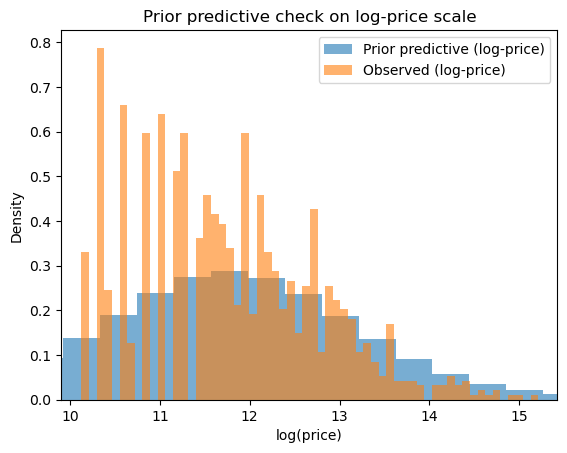

In [118]:
# Extract arrays
y_obs = prior_idata.observed_data["y_obs"].values
y_prior = prior_idata.prior_predictive["y_obs"].values

# Flatten prior draws across chains/draws (robust to dimensionality)
y_prior_flat = y_prior.reshape(-1, y_prior.shape[-1])  # (n_draws_total, n_obs)
y_prior_1d = y_prior_flat.ravel()

log_floor_vis = np.log(20_000)     # visualization only
log_ceiling_vis = np.log(5_000_000)


plt.figure()
plt.hist(y_prior_1d, bins=80, alpha=0.6, density=True, label="Prior predictive (log-price)")
plt.hist(y_obs, bins=60, alpha=0.6, density=True, label="Observed (log-price)")
plt.title("Prior predictive check on log-price scale")
plt.xlabel("log(price)")
plt.ylabel("Density")
plt.xlim(log_floor_vis, log_ceiling_vis)
plt.legend()
plt.show()


In [29]:
(p_over := (y_prior_1d > np.log(5_000_000)).mean())


0.00949774368231047

In [201]:
# =========================================================
# CELL 7: PREDICTION FUNCTION
# =========================================================

def predict_final(idata, X_scaled, sire_idx, dam_sire_idx, breeder_idx):
    """
    Predict with final model.
    Handles new groups (unseen sires/dam_sires/breeders) by using 0 for their effect.
    """
    intercept = idata.posterior['intercept'].mean(dim=['chain', 'draw']).values
    beta = idata.posterior['beta'].mean(dim=['chain', 'draw']).values
   # year_coef = idata.posterior['year_coef'].mean(dim=['chain', 'draw']).values
   # auction_coef = idata.posterior['auction_coef'].mean(dim=['chain', 'draw']).values
    alpha_sire = idata.posterior['alpha_sire'].mean(dim=['chain', 'draw']).values
    alpha_dam_sire = idata.posterior['alpha_dam_sire'].mean(dim=['chain', 'draw']).values
    alpha_breeder = idata.posterior['alpha_breeder'].mean(dim=['chain', 'draw']).values
    
    n = len(X_scaled)
    predictions = (np.full(n, intercept) + 
                   X_scaled @ beta )
                 #  year_coef * year_vals +
                 #  auction_coef * auction_binary)
    
    # Add random effects (0 for new/unseen groups)
    for i in range(n):
        if sire_idx[i] >= 0:
            predictions[i] += alpha_sire[sire_idx[i]]
        if dam_sire_idx[i] >= 0:
            predictions[i] += alpha_dam_sire[dam_sire_idx[i]]
        if breeder_idx[i] >= 0:
            predictions[i] += alpha_breeder[breeder_idx[i]]
    
    return predictions

print("✓ Prediction function defined")

✓ Prediction function defined


In [203]:
# =========================================================
# OUT-OF-FOLD SIGMA² ESTIMATION (BHM)
# =========================================================

print("="*70)
print("OUT-OF-FOLD SIGMA² ESTIMATION (BHM)")
print("="*70)

# ---------------------------------------------------------
# 1. Define temporal folds
# ---------------------------------------------------------
years = df_train[col_year].unique()
print(f"\n[TEMPORAL FOLDS]")
print(f"  Years in training data: {sorted(years)}")

oof_predictions = np.zeros(len(y_train))
oof_actuals = np.zeros(len(y_train))

# ---------------------------------------------------------
# 2. Fit model for each fold
# ---------------------------------------------------------
for fold, val_year in enumerate(sorted(years)):
    print(f"\n[FOLD {fold+1}] Train on {[y for y in years if y != val_year]} → Predict {val_year}")
    
    # Split data
    train_mask = df_train[col_year] != val_year
    val_mask = df_train[col_year] == val_year
    
    fold_train_idx = np.where(train_mask)[0]
    fold_val_idx = np.where(val_mask)[0]
    
    print(f"  Train size: {len(fold_train_idx)}, Val size: {len(fold_val_idx)}")
    
    # Prepare fold-specific data
    X_fold_train = X_train_scaled[fold_train_idx]
    X_fold_val = X_train_scaled[fold_val_idx]
    y_fold_train = y_train[fold_train_idx]
    y_fold_val = y_train[fold_val_idx]
    
    # Get fold-specific indices for random effects
    fold_train_sire_idx = train_sire_idx[fold_train_idx]
    fold_train_dam_sire_idx = train_dam_sire_idx[fold_train_idx]
    fold_train_breeder_idx = train_breeder_idx[fold_train_idx]
    
    fold_val_sire_idx = train_sire_idx[fold_val_idx]
    fold_val_dam_sire_idx = train_dam_sire_idx[fold_val_idx]
    fold_val_breeder_idx = train_breeder_idx[fold_val_idx]
    
    # Year and auction for fold
   # fold_year_train = year_centered_train[fold_train_idx]
   # fold_year_val = year_centered_train[fold_val_idx]
   # fold_auction_train = auction_binary_train[fold_train_idx]
   # fold_auction_val = auction_binary_train[fold_val_idx]
    
    # Build fold model
    with pm.Model() as fold_model:
        intercept = pm.Normal('intercept', mu=y_fold_train.mean(), sigma=0.35)
        beta = pm.Normal('beta', mu=0, sigma=0.25, shape=X_fold_train.shape[1])
        #year_coef = pm.Normal('year_coef', mu=0.05, sigma=0.15)
        #auction_coef = pm.Normal('auction_coef', mu=0.15, sigma=0.1)
        
        sigma_sire = pm.HalfNormal('sigma_sire', sigma=0.35)
        alpha_sire_raw = pm.Normal('alpha_sire_raw', mu=0, sigma=1, shape=n_sires)
        alpha_sire = pm.Deterministic('alpha_sire', alpha_sire_raw * sigma_sire)
        
        sigma_dam_sire = pm.HalfNormal('sigma_dam_sire', sigma=0.20)
        alpha_dam_sire_raw = pm.Normal('alpha_dam_sire_raw', mu=0, sigma=1, shape=n_dam_sires)
        alpha_dam_sire = pm.Deterministic('alpha_dam_sire', alpha_dam_sire_raw * sigma_dam_sire)
        
        sigma_breeder = pm.HalfNormal('sigma_breeder', sigma=0.25)
        alpha_breeder_raw = pm.Normal('alpha_breeder_raw', mu=0, sigma=1, shape=n_breeders)
        alpha_breeder = pm.Deterministic('alpha_breeder', alpha_breeder_raw * sigma_breeder)
        
        sigma = pm.HalfNormal('sigma', sigma=0.30)
        
        mu = (intercept + 
              pm.math.dot(X_fold_train, beta) + 
           #   year_coef * fold_year_train +
           #   auction_coef * fold_auction_train +
              alpha_sire[fold_train_sire_idx] + 
              alpha_dam_sire[fold_train_dam_sire_idx] +
              alpha_breeder[fold_train_breeder_idx])
        
        y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_fold_train)
    
    # Sample
    with fold_model:
        idata_fold = pm.sample(
            draws=500, tune=1000, chains=2,
            target_accept=0.95, random_seed=42,
            progressbar=True, return_inferencedata=True
        )
    
    # Predict on validation fold
    fold_pred = predict_final(
        idata_fold, X_fold_val,
        fold_val_sire_idx, fold_val_dam_sire_idx, fold_val_breeder_idx
    )
    
    # Store OOF predictions
    oof_predictions[fold_val_idx] = fold_pred
    oof_actuals[fold_val_idx] = y_fold_val
    
    fold_rmse = np.sqrt(np.mean((y_fold_val - fold_pred)**2))
    print(f"  Fold RMSE: {fold_rmse:.4f}")

# ---------------------------------------------------------
# 3. Calculate OOF sigma (FINAL RESULT)
# ---------------------------------------------------------
oof_residuals = oof_actuals - oof_predictions
sigma2_oof = np.var(oof_residuals)
sigma_oof = np.std(oof_residuals)

print(f"\n" + "="*70)
print("OOF SIGMA RESULTS")
print("="*70)

print(f"\n[OOF SIGMA]")
print(f"  σ_oof:   {sigma_oof:.4f}")
print(f"  σ²_oof:  {sigma2_oof:.4f}")
print(f"  RMSE:    {np.sqrt(np.mean(oof_residuals**2)):.4f}")

print(f"\n[BIAS CORRECTION FACTOR]")
print(f"  exp(σ²_oof / 2) = {np.exp(sigma2_oof/2):.4f}")

print(f"\n✓ Use sigma_oof = {sigma_oof:.4f} for price conversion")


OUT-OF-FOLD SIGMA² ESTIMATION (BHM)

[TEMPORAL FOLDS]
  Years in training data: [2023, 2024]

[FOLD 1] Train on [2024] → Predict 2023
  Train size: 539, Val size: 569


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta, sigma_sire, alpha_sire_raw, sigma_dam_sire, alpha_dam_sire_raw, sigma_breeder, alpha_breeder_raw, sigma]


Output()

Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 129 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


  Fold RMSE: 0.6485

[FOLD 2] Train on [2023] → Predict 2024
  Train size: 569, Val size: 539


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta, sigma_sire, alpha_sire_raw, sigma_dam_sire, alpha_dam_sire_raw, sigma_breeder, alpha_breeder_raw, sigma]


Output()

Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 85 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  Fold RMSE: 0.6911

OOF SIGMA RESULTS

[OOF SIGMA]
  σ_oof:   0.6692
  σ²_oof:  0.4478
  RMSE:    0.6696

[BIAS CORRECTION FACTOR]
  exp(σ²_oof / 2) = 1.2510

✓ Use sigma_oof = 0.6692 for price conversion


In [229]:
# =========================================================
# OOF PERFORMANCE METRICS (BHM)
# =========================================================

print("="*70)
print("OUT-OF-FOLD PERFORMANCE METRICS (BHM)")
print("="*70)

# OOF predictions already exist from sigma estimation
# oof_predictions (log scale)
# oof_actuals (log scale)

# ---------------------------------------------------------
# Log scale metrics
# ---------------------------------------------------------
oof_r2_log = r2_score(oof_actuals, oof_predictions)
oof_rmse_log = np.sqrt(mean_squared_error(oof_actuals, oof_predictions))
oof_mae_log = mean_absolute_error(oof_actuals, oof_predictions)

print(f"\n[OOF METRICS - LOG SCALE]")
print(f"  R²:   {oof_r2_log:.4f}")
print(f"  RMSE: {oof_rmse_log:.4f}")
print(f"  MAE:  {oof_mae_log:.4f}")

# ---------------------------------------------------------
# Price scale metrics (no correction)
# ---------------------------------------------------------
oof_actuals_price = np.exp(oof_actuals)
oof_predictions_price = np.exp(oof_predictions)

oof_r2_price = r2_score(oof_actuals_price, oof_predictions_price)
oof_rmse_price = np.sqrt(mean_squared_error(oof_actuals_price, oof_predictions_price))  # ADD
oof_mae_price = mean_absolute_error(oof_actuals_price, oof_predictions_price)  # ADD
oof_mdape = np.median(np.abs((oof_actuals_price - oof_predictions_price) / oof_actuals_price)) * 100
oof_mape = np.mean(np.abs((oof_actuals_price - oof_predictions_price) / oof_actuals_price)) * 100

print(f"\n[OOF METRICS - PRICE SCALE]")
print(f"  R²:    {oof_r2_price:.4f}")
print(f"  RMSE:  {oof_rmse_price:,.0f} SEK")  
print(f"  MAE:   {oof_mae_price:,.0f} SEK")  
print(f"  MdAPE: {oof_mdape:.1f}%")
print(f"  MAPE:  {oof_mape:.1f}%")


# ---------------------------------------------------------
# Ranking metrics
# ---------------------------------------------------------
from scipy.stats import spearmanr
oof_spearman, _ = spearmanr(oof_actuals_price, oof_predictions_price)

print(f"\n[OOF RANKING]")
print(f"  Spearman: {oof_spearman:.4f}")

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------
print(f"\n[OOF SUMMARY]")
print(f"  OOF R² (log):   {oof_r2_log:.4f}")
print(f"  OOF R² (price): {oof_r2_price:.4f}")
print(f"  OOF RMSE:       {oof_rmse_price:,.0f} SEK")  
print(f"  OOF MAE:        {oof_mae_price:,.0f} SEK")  
print(f"  OOF MdAPE:      {oof_mdape:.1f}%")
print(f"  OOF Spearman:   {oof_spearman:.4f}")
print(f"  OOF σ:          {sigma_oof:.4f}")

print(f"\n✓ OOF metrics calculated")

OUT-OF-FOLD PERFORMANCE METRICS (BHM)

[OOF METRICS - LOG SCALE]
  R²:   0.5589
  RMSE: 0.6696
  MAE:  0.5362

[OOF METRICS - PRICE SCALE]
  R²:    0.3033
  RMSE:  285,143 SEK
  MAE:   118,216 SEK
  MdAPE: 43.8%
  MAPE:  61.8%

[OOF RANKING]
  Spearman: 0.7397

[OOF SUMMARY]
  OOF R² (log):   0.5589
  OOF R² (price): 0.3033
  OOF RMSE:       285,143 SEK
  OOF MAE:        118,216 SEK
  OOF MdAPE:      43.8%
  OOF Spearman:   0.7397
  OOF σ:          0.6692

✓ OOF metrics calculated


In [207]:
# =========================================================
# CELL 8: FIT FINAL MODEL
# =========================================================

print("="*70)
print("FITTING FINAL MODEL")
print("="*70)


config = PRIOR_CONFIGS['informed']
print(f"\nUsing: {config['name']}")

model_final = build_final_model(config)

print("\nSampling (4 chains × 1000 draws)...")
print("This will take 2-5 minutes...\n")

with model_final:
    idata_final = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.98,
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True
    )

print(f"\n✓ Sampling complete!")
print(f"  Divergences: {idata_final.sample_stats.diverging.values.sum()}")

FITTING FINAL MODEL

Using: Informed Priors (RECOMMENDED)

Sampling (4 chains × 1000 draws)...
This will take 2-5 minutes...



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, sigma_sire, alpha_sire_raw, sigma_dam_sire, alpha_dam_sire_raw, sigma_breeder, alpha_breeder_raw, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 141 seconds.



✓ Sampling complete!
  Divergences: 0


In [219]:
# =========================================================
# CELL 9: CONVERGENCE DIAGNOSTICS
# =========================================================

print("="*70)
print("CONVERGENCE DIAGNOSTICS")
print("="*70)

var_names = ['intercept', 'beta',
             'sigma_sire', 'sigma_dam_sire', 'sigma_breeder', 'sigma']

summary = az.summary(idata_final, var_names=var_names)
print("\n[PARAMETER SUMMARY]")
print(summary[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

rhat_max = summary['r_hat'].max()
ess_min = summary['ess_bulk'].min()

print(f"\n[CONVERGENCE CHECK]")
print(f"  Max R-hat: {rhat_max:.4f}")
print(f"  Min ESS:   {ess_min:.0f}")

if rhat_max < 1.01:
    print("  ✓ Chains converged (R-hat < 1.01)")
else:
    print("  ⚠ Chains may not have converged!")

if ess_min > 400:
    print("  ✓ Sufficient effective samples (ESS > 400)")
else:
    print("  ⚠ Low effective sample size for some parameters")

# Fixed effect interpretation
#print(f"\n[FIXED EFFECT ESTIMATES]")
#year_mean = idata_final.posterior['year_coef'].mean().values
#auction_mean = idata_final.posterior['auction_coef'].mean().values
#print(f"  Year:    {year_mean:.4f} ({(np.exp(year_mean)-1)*100:.1f}% per year)")
#print(f"  Auction: {auction_mean:.4f} ({(np.exp(auction_mean)-1)*100:.1f}% selective premium)")

CONVERGENCE DIAGNOSTICS

[PARAMETER SUMMARY]
                  mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
intercept       11.742  0.045  11.658   11.827    1.0    3157.0
beta[0]         -0.072  0.036  -0.137   -0.004    1.0    5280.0
beta[1]         -0.031  0.032  -0.087    0.033    1.0    5497.0
beta[2]          0.051  0.024   0.004    0.094    1.0    5267.0
beta[3]          0.443  0.045   0.359    0.529    1.0    3330.0
beta[4]         -0.004  0.044  -0.084    0.080    1.0    3313.0
beta[5]         -0.006  0.030  -0.064    0.050    1.0    5544.0
beta[6]          0.019  0.022  -0.020    0.062    1.0    6762.0
beta[7]         -0.072  0.019  -0.108   -0.036    1.0    7537.0
beta[8]          0.108  0.053   0.006    0.203    1.0    5721.0
beta[9]          0.024  0.025  -0.023    0.070    1.0    7464.0
beta[10]         0.022  0.023  -0.022    0.065    1.0    7113.0
beta[11]        -0.060  0.028  -0.112   -0.007    1.0    6411.0
beta[12]         0.116  0.026   0.069    0.167    1.0    59

In [221]:
# ---------------------------------------------------------
# Table X: Convergence Diagnostics
# ---------------------------------------------------------
doc.add_heading('Table X: BHM Convergence Diagnostics', level=2)

# Get summary statistics
var_names = ['intercept', 'beta', 'sigma_sire', 'sigma_dam_sire', 'sigma_breeder', 'sigma']
summary = az.summary(idata_final, var_names=var_names)

# Key convergence metrics
rhat_max = summary['r_hat'].max()
rhat_min = summary['r_hat'].min()
ess_min = summary['ess_bulk'].min()
ess_max = summary['ess_bulk'].max()
n_params = len(summary)

# Create summary table
table_conv = doc.add_table(rows=6, cols=2)
table_conv.style = 'Table Grid'

# Header
table_conv.rows[0].cells[0].text = 'Diagnostic'
table_conv.rows[0].cells[1].text = 'Value'

# Data rows
table_conv.rows[1].cells[0].text = 'Number of parameters'
table_conv.rows[1].cells[1].text = f'{n_params}'

table_conv.rows[2].cells[0].text = 'R-hat (max)'
table_conv.rows[2].cells[1].text = f'{rhat_max:.3f}'

table_conv.rows[3].cells[0].text = 'R-hat (range)'
table_conv.rows[3].cells[1].text = f'{rhat_min:.3f} – {rhat_max:.3f}'

table_conv.rows[4].cells[0].text = 'ESS bulk (min)'
table_conv.rows[4].cells[1].text = f'{ess_min:.0f}'

table_conv.rows[5].cells[0].text = 'ESS bulk (range)'
table_conv.rows[5].cells[1].text = f'{ess_min:.0f} – {ess_max:.0f}'

doc.add_paragraph('')  # Spacer

# Add convergence status
status = []
if rhat_max < 1.01:
    status.append('✓ Chains converged (R-hat < 1.01)')
else:
    status.append('⚠ Convergence issues (R-hat ≥ 1.01)')

if ess_min > 400:
    status.append('✓ Sufficient effective samples (ESS > 400)')
else:
    status.append('⚠ Low effective sample size')

doc.add_paragraph('Convergence Status: ' + '; '.join(status))
doc.add_paragraph('(Source: own representation)')

In [223]:
# ---------------------------------------------------------
# Add Convergence Diagnostics to existing doc
# ---------------------------------------------------------
doc.add_heading('Table X: BHM Convergence Diagnostics', level=2)

# Get summary statistics
var_names = ['intercept', 'beta', 'sigma_sire', 'sigma_dam_sire', 'sigma_breeder', 'sigma']
summary = az.summary(idata_final, var_names=var_names)

rhat_max = summary['r_hat'].max()
rhat_min = summary['r_hat'].min()
ess_min = summary['ess_bulk'].min()
ess_max = summary['ess_bulk'].max()
n_params = len(summary)

table_conv = doc.add_table(rows=6, cols=2)
table_conv.style = 'Table Grid'

table_conv.rows[0].cells[0].text = 'Diagnostic'
table_conv.rows[0].cells[1].text = 'Value'

table_conv.rows[1].cells[0].text = 'Number of parameters'
table_conv.rows[1].cells[1].text = f'{n_params}'

table_conv.rows[2].cells[0].text = 'R-hat (max)'
table_conv.rows[2].cells[1].text = f'{rhat_max:.3f}'

table_conv.rows[3].cells[0].text = 'R-hat (range)'
table_conv.rows[3].cells[1].text = f'{rhat_min:.3f} – {rhat_max:.3f}'

table_conv.rows[4].cells[0].text = 'ESS bulk (min)'
table_conv.rows[4].cells[1].text = f'{ess_min:.0f}'

table_conv.rows[5].cells[0].text = 'ESS bulk (range)'
table_conv.rows[5].cells[1].text = f'{ess_min:.0f} – {ess_max:.0f}'

doc.add_paragraph('(Source: own representation)')

# Save at the end of your export cell
doc.save('BHM_Results_Tables.docx')
print("✓ Saved: BHM_Results_Tables.docx")

✓ Saved: BHM_Results_Tables.docx


In [211]:
# =========================================================
# MODEL EVALUATION
# =========================================================

print("="*70)
print("MODEL EVALUATION")
print("="*70)

# ---------------------------------------------------------
# 1. Generate predictions (log scale)
# ---------------------------------------------------------
pred_train_log = predict_final(idata_final, X_train_scaled, 
                                train_sire_idx, train_dam_sire_idx, train_breeder_idx)
                                #year_centered_train, auction_binary_train)

pred_test_log = predict_final(idata_final, X_test_scaled,
                               test_sire_idx, test_dam_sire_idx, test_breeder_idx)
                               #year_centered_test, auction_binary_test)

# Actual prices
y_train_price = np.exp(y_train)
y_test_price = np.exp(y_test)

# ---------------------------------------------------------
# 2. Log scale metrics
# ---------------------------------------------------------
train_r2_log = r2_score(y_train, pred_train_log)
test_r2_log = r2_score(y_test, pred_test_log)
train_rmse_log = np.sqrt(mean_squared_error(y_train, pred_train_log))
train_mae_log = mean_absolute_error(y_train, pred_train_log)
test_rmse_log = np.sqrt(mean_squared_error(y_test, pred_test_log))
test_mae_log = mean_absolute_error(y_test, pred_test_log)


print(f"\n[LOG SCALE METRICS]")
print(f"  Train R²:  {train_r2_log:.4f}")
print(f"  Test R²:   {test_r2_log:.4f}")
print(f"  Gap:       {train_r2_log - test_r2_log:.4f}")
print(f"  Train RMSE: {train_rmse_log:.4f}")
print(f"  Train MAE:  {train_mae_log:.4f}")
print(f"  Test RMSE: {test_rmse_log:.4f}")
print(f"  Test MAE:  {test_mae_log:.4f}")

# ---------------------------------------------------------
# 3. Price scale conversion - Compare methods
# ---------------------------------------------------------
print(f"\n[PRICE SCALE CONVERSION - METHOD COMPARISON]")

# OOF sigma from temporal fold analysis
#sigma_oof = 0.6702
sigma2_oof = sigma_oof**2

# Posterior sigma
sigma_posterior = float(idata_final.posterior['sigma'].mean().values)
sigma2_posterior = sigma_posterior**2

print(f"\n  Sigma estimates:")
print(f"    Posterior σ: {sigma_posterior:.4f}")
print(f"    OOF σ:       {sigma_oof:.4f}")

# Option A: No correction
pred_test_price_none = np.exp(pred_test_log)
r2_none = r2_score(y_test_price, pred_test_price_none)
mean_err_none = np.mean(y_test_price - pred_test_price_none)
mdape_none = np.median(np.abs((y_test_price - pred_test_price_none) / y_test_price)) * 100
mape_none = np.mean(np.abs((y_test_price - pred_test_price_none) / y_test_price)) * 100

# Option B: OOF correction
pred_test_price_oof = np.exp(pred_test_log + sigma2_oof/2)
r2_oof = r2_score(y_test_price, pred_test_price_oof)
mean_err_oof = np.mean(y_test_price - pred_test_price_oof)
mdape_oof = np.median(np.abs((y_test_price - pred_test_price_oof) / y_test_price)) * 100
mape_oof = np.mean(np.abs((y_test_price - pred_test_price_oof) / y_test_price)) * 100

# Option C: Posterior correction
pred_test_price_post = np.exp(pred_test_log + sigma2_posterior/2)
r2_post = r2_score(y_test_price, pred_test_price_post)
mean_err_post = np.mean(y_test_price - pred_test_price_post)
mdape_post = np.median(np.abs((y_test_price - pred_test_price_post) / y_test_price)) * 100
mape_post = np.mean(np.abs((y_test_price - pred_test_price_post) / y_test_price)) * 100

print(f"\n  {'Method':<20} {'R²':>8} {'Mean Error':>14} {'MdAPE':>8} {'MAPE':>8} {'Factor':>8}")
print(f"  {'-'*72}")
print(f"  {'No correction':<20} {r2_none:>8.4f} {mean_err_none:>+13,.0f} {mdape_none:>7.1f}% {mape_none:>7.1f}% {1.0:>8.4f}")
print(f"  {'Posterior σ²/2':<20} {r2_post:>8.4f} {mean_err_post:>+13,.0f} {mdape_post:>7.1f}% {mape_post:>7.1f}% {np.exp(sigma2_posterior/2):>8.4f}")
print(f"  {'OOF σ²/2':<20} {r2_oof:>8.4f} {mean_err_oof:>+13,.0f} {mdape_oof:>7.1f}% {mape_oof:>7.1f}% {np.exp(sigma2_oof/2):>8.4f}")

# ---------------------------------------------------------
# 4. SELECT CONVERSION METHOD
# ---------------------------------------------------------

# OPTION A: No correction (best R², predicts median)
pred_train_price_bhm = np.exp(pred_train_log)
pred_test_price_bhm = np.exp(pred_test_log)
conversion_method = "No correction (predicts median)"
selected_r2 = r2_none
selected_mdape = mdape_none
selected_mape = mape_none
selected_mean_err = mean_err_none

# # OPTION B: OOF correction (lower mean error, predicts mean)
#pred_train_price_bhm = np.exp(pred_train_log + sigma2_oof/2)
#pred_test_price_bhm = np.exp(pred_test_log + sigma2_oof/2)
#conversion_method = f"OOF σ²/2 (factor = {np.exp(sigma2_oof/2):.4f})"
#selected_r2 = r2_oof
#selected_mdape = mdape_oof
#selected_mape = mape_oof
#selected_mean_err = mean_err_oof

print(f"\n  Selected: {conversion_method}")

# ---------------------------------------------------------
# 5. Final price scale metrics
# ---------------------------------------------------------

test_rmse_price = np.sqrt(mean_squared_error(y_test_price, pred_test_price_bhm))
test_mae_price = mean_absolute_error(y_test_price, pred_test_price_bhm)

print(f"\n[PRICE SCALE METRICS]")
print(f"  Test R²:      {selected_r2:.4f}")
print(f"  MdAPE:        {selected_mdape:.1f}%")
print(f"  MAPE:         {selected_mape:.1f}%")
print(f"  Mean Error:   {selected_mean_err:+,.0f} SEK")
print(f"  Median Error: {np.median(y_test_price - pred_test_price_bhm):+,.0f} SEK")


# ---------------------------------------------------------
# 6. Ranking metrics
# ---------------------------------------------------------
from scipy.stats import spearmanr, kendalltau

spearman_corr, _ = spearmanr(y_test_price, pred_test_price_bhm)
kendall_corr, _ = kendalltau(y_test_price, pred_test_price_bhm)

print(f"\n[RANKING METRICS]")
print(f"  Spearman:    {spearman_corr:.4f}")
print(f"  Kendall τ:   {kendall_corr:.4f}")

# ---------------------------------------------------------
# 7. Summary
# ---------------------------------------------------------
print(f"\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"""
  Model:              BHM (PyMC)
  Conversion:         {conversion_method}
  
  Log Scale:
    Train R²:         {train_r2_log:.4f}
    Test R²:          {test_r2_log:.4f}
  
  Price Scale:
    Test R²:          {selected_r2:.4f}
    MdAPE:            {selected_mdape:.1f}%
    Spearman:         {spearman_corr:.4f}
  
  OOF σ available:    {sigma_oof:.4f} (for uncertainty estimation)
""")

print("✓ pred_train_price_bhm and pred_test_price_bhm created")

# OOF metrics (if not already calculated)
oof_actuals_price = np.exp(oof_actuals)
oof_predictions_price = np.exp(oof_predictions)
oof_r2_price = r2_score(oof_actuals_price, oof_predictions_price)
oof_rmse_price = np.sqrt(mean_squared_error(oof_actuals_price, oof_predictions_price))
oof_mae_price = mean_absolute_error(oof_actuals_price, oof_predictions_price)
oof_mdape = np.median(np.abs((oof_actuals_price - oof_predictions_price) / oof_actuals_price)) * 100
oof_spearman, _ = spearmanr(oof_actuals_price, oof_predictions_price)

# Test metrics
test_r2_log = r2_score(y_test, pred_test_log)
test_r2_price = r2_score(y_test_price, pred_test_price_bhm)
test_rmse_price = np.sqrt(mean_squared_error(y_test_price, pred_test_price_bhm))
test_mae_price = mean_absolute_error(y_test_price, pred_test_price_bhm)
test_mdape = np.median(np.abs((y_test_price - pred_test_price_bhm) / y_test_price)) * 100
spearman_corr, _ = spearmanr(y_test_price, pred_test_price_bhm)

print(f"\n[COMPARISON: OOF vs TEST]")
print(f"\n  {'Metric':<15} {'OOF':>12} {'Test':>12}")
print(f"  {'-'*40}")
print(f"  {'R² (log)':<15} {oof_r2_log:>12.4f} {test_r2_log:>12.4f}")
print(f"  {'R² (price)':<15} {oof_r2_price:>12.4f} {selected_r2:>12.4f}")

print(f"  {'RMSE (SEK)':<15} {oof_rmse_price:>12,.0f} {test_rmse_price:>12,.0f}")
print(f"  {'MAE (SEK)':<15} {oof_mae_price:>12,.0f} {test_mae_price:>12,.0f}")
print(f"  {'MdAPE':<15} {oof_mdape:>11.1f}% {selected_mdape:>11.1f}%")
print(f"  {'Spearman':<15} {oof_spearman:>12.4f} {spearman_corr:>12.4f}")

MODEL EVALUATION

[LOG SCALE METRICS]
  Train R²:  0.7099
  Test R²:   0.4295
  Gap:       0.2805
  Train RMSE: 0.5430
  Train MAE:  0.4352
  Test RMSE: 0.7530
  Test MAE:  0.6222

[PRICE SCALE CONVERSION - METHOD COMPARISON]

  Sigma estimates:
    Posterior σ: 0.5870
    OOF σ:       0.6692

  Method                     R²     Mean Error    MdAPE     MAPE   Factor
  ------------------------------------------------------------------------
  No correction          0.3638       +51,815    52.5%    71.5%   1.0000
  Posterior σ²/2         0.3627       +12,763    52.5%    85.9%   1.1880
  OOF σ²/2               0.3487          -314    53.5%    91.2%   1.2510

  Selected: No correction (predicts median)

[PRICE SCALE METRICS]
  Test R²:      0.3638
  MdAPE:        52.5%
  MAPE:         71.5%
  Mean Error:   +51,815 SEK
  Median Error: +3,151 SEK

[RANKING METRICS]
  Spearman:    0.6722
  Kendall τ:   0.4830

SUMMARY

  Model:              BHM (PyMC)
  Conversion:         No correction (pred

PREDICTIONS FOR ALL HORSES

[PREDICTIONS GENERATED]
  Train: 1108 horses
  Test:  510 horses
  Test R² (log):   0.4295
  Test R² (price): 0.3638

[SAMPLE PREDICTIONS - TEST SET]
              Name Dataset                Sire  Year auction_type  Actual_Price  Predicted_Price  Error_SEK  Error_Pct  Abs_Error_Pct
       Gloria Wynn    Test Father Patrick (US)  2025     Standard         30000            92425      62425      208.1          208.1
     Ocean Journey    Test      Greenshoe (US)  2025     Standard        260000           118353    -141647      -54.5           54.5
       Pure Sharif    Test       Ecurie D (DK)  2025     Standard         50000           113359      63359      126.7          126.7
License to Impress    Test  Captain Corey (US)  2025     Standard         50000            96806      46806       93.6           93.6
            Hatman    Test      Readly Express  2025     Standard        140000           230138      90138       64.4           64.4
      Warning Tile

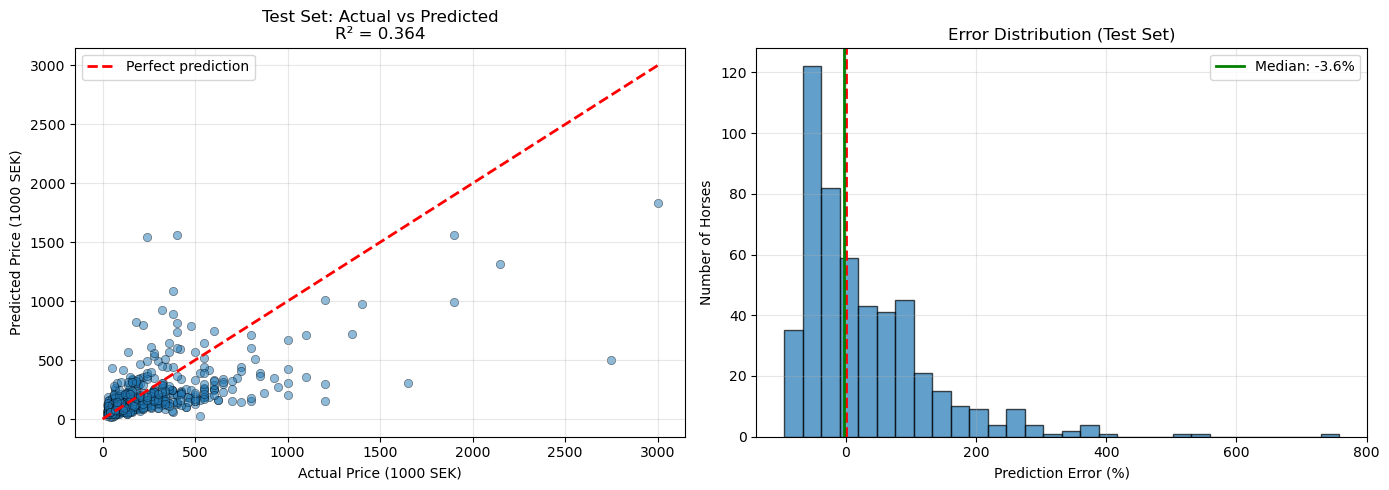


✓ Saved visualization to: BHM_prediction_analysis.png


In [132]:
# =========================================================
# GENERATE PREDICTIONS FOR ALL HORSES
# =========================================================

print("="*70)
print("PREDICTIONS FOR ALL HORSES")
print("="*70)

# ---------------------------------------------------------
# 1. Generate predictions (log scale)
# ---------------------------------------------------------
pred_train_log = predict_final(idata_final, X_train_scaled, 
                                train_sire_idx, train_dam_sire_idx, train_breeder_idx)
                               # year_centered_train, auction_binary_train)

pred_test_log = predict_final(idata_final, X_test_scaled,
                               test_sire_idx, test_dam_sire_idx, test_breeder_idx)
                               #year_centered_test, auction_binary_test)

# ---------------------------------------------------------
# 2. Convert to price scale (NO CORRECTION - predicts median)
# ---------------------------------------------------------
pred_train_price_bhm = np.exp(pred_train_log)
pred_test_price_bhm = np.exp(pred_test_log)


# ---------------------------------------------------------
# 2. Convert to price scale (WITH OOF BIAS CORRECTION)
# ---------------------------------------------------------
# Apply bias correction: exp(log_pred) gives median, multiply by exp(σ²/2) for mean
#bias_correction = np.exp(sigma2_oof / 2)
#print(f"  Bias correction factor: {bias_correction:.4f}")

#pred_train_price_bhm = np.exp(pred_train_log) * bias_correction
#pred_test_price_bhm = np.exp(pred_test_log) * bias_correction

# Actual prices
y_train_price = np.exp(y_train)
y_test_price = np.exp(y_test)

# Calculate metrics
test_r2_log = r2_score(y_test, pred_test_log)
test_r2_price = r2_score(y_test_price, pred_test_price_bhm)

print(f"\n[PREDICTIONS GENERATED]")
print(f"  Train: {len(pred_train_log)} horses")
print(f"  Test:  {len(pred_test_log)} horses")
print(f"  Test R² (log):   {test_r2_log:.4f}")
print(f"  Test R² (price): {test_r2_price:.4f}")

# ---------------------------------------------------------
# 3. Create results DataFrames
# ---------------------------------------------------------

# Find the horse name column
col_name = find_col(df, ['Name', 'Horse', 'Horse Name'])
if col_name:
    col_name = rename_mapping.get(col_name, col_name)

# Training set results
train_results = df_train.copy()
train_results['Predicted_Log'] = pred_train_log
train_results['Predicted_Price'] = pred_train_price_bhm  # Fixed variable name
train_results['Actual_Price'] = y_train_price
train_results['Error_SEK'] = train_results['Predicted_Price'] - train_results['Actual_Price']
train_results['Error_Pct'] = (train_results['Error_SEK'] / train_results['Actual_Price']) * 100
train_results['Abs_Error_Pct'] = np.abs(train_results['Error_Pct'])
train_results['Dataset'] = 'Train'

# Test set results
test_results = df_test.copy()
test_results['Predicted_Log'] = pred_test_log
test_results['Predicted_Price'] = pred_test_price_bhm  # Fixed variable name
test_results['Actual_Price'] = y_test_price
test_results['Error_SEK'] = test_results['Predicted_Price'] - test_results['Actual_Price']
test_results['Error_Pct'] = (test_results['Error_SEK'] / test_results['Actual_Price']) * 100
test_results['Abs_Error_Pct'] = np.abs(test_results['Error_Pct'])
test_results['Dataset'] = 'Test'

# Combine
all_results = pd.concat([train_results, test_results], ignore_index=True)

# ---------------------------------------------------------
# 4. Select columns for display
# ---------------------------------------------------------

# Core columns to display
display_cols = ['Dataset', col_sire, col_year, 'auction_type', 
                'Actual_Price', 'Predicted_Price', 'Error_SEK', 'Error_Pct']

# Add horse name if available
if col_name and col_name in all_results.columns:
    display_cols = [col_name] + display_cols

# Create display DataFrame
results_display = all_results[display_cols].copy()
results_display['Actual_Price'] = results_display['Actual_Price'].round(0).astype(int)
results_display['Predicted_Price'] = results_display['Predicted_Price'].round(0).astype(int)
results_display['Error_SEK'] = results_display['Error_SEK'].round(0).astype(int)
results_display['Error_Pct'] = results_display['Error_Pct'].round(1)

# Add Abs_Error_Pct for sorting
results_display['Abs_Error_Pct'] = np.abs(results_display['Error_Pct'])

# ---------------------------------------------------------
# 5. Display sample predictions
# ---------------------------------------------------------

print(f"\n[SAMPLE PREDICTIONS - TEST SET]")
print(results_display[results_display['Dataset'] == 'Test'].head(20).to_string(index=False))
# ---------------------------------------------------------
# 6. Best and worst predictions
# ---------------------------------------------------------

test_display = results_display[results_display['Dataset'] == 'Test'].copy()

print(f"\n[BEST PREDICTIONS (Test Set) - Lowest Absolute Error]")
best = test_display.nsmallest(10, 'Abs_Error_Pct')
print(best.drop(columns=['Abs_Error_Pct']).to_string(index=False))

print(f"\n[WORST PREDICTIONS (Test Set) - Highest Overestimates]")
worst_over = test_display.nlargest(10, 'Error_Pct')
print(worst_over.drop(columns=['Abs_Error_Pct']).to_string(index=False))

print(f"\n[WORST PREDICTIONS (Test Set) - Highest Underestimates]")
worst_under = test_display.nsmallest(10, 'Error_Pct')
print(worst_under.drop(columns=['Abs_Error_Pct']).to_string(index=False))

# ---------------------------------------------------------
# 7. Save to Excel
# ---------------------------------------------------------

output_file = 'BHM_horse_predictions.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # All predictions
    results_display.to_excel(writer, sheet_name='All_Predictions', index=False)
    
    # Test only
    results_display[results_display['Dataset'] == 'Test'].to_excel(
        writer, sheet_name='Test_Predictions', index=False)
    
    # Summary stats by sire
    sire_summary = all_results.groupby([col_sire, 'Dataset']).agg({
        'Actual_Price': ['mean', 'count'],
        'Predicted_Price': 'mean',
        'Abs_Error_Pct': 'mean'
    }).round(0)
    sire_summary.columns = ['Avg_Actual', 'Count', 'Avg_Predicted', 'Avg_Abs_Error_Pct']
    sire_summary.to_excel(writer, sheet_name='By_Sire')

print(f"\n✓ Saved predictions to: {output_file}")
print(f"  - Sheet 'All_Predictions': All {len(all_results)} horses")
print(f"  - Sheet 'Test_Predictions': {len(test_results)} test horses")
print(f"  - Sheet 'By_Sire': Summary by sire")

# ---------------------------------------------------------
# 8. Quick visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted (Test set)
ax1 = axes[0]
ax1.scatter(test_results['Actual_Price']/1000, test_results['Predicted_Price']/1000, 
            alpha=0.5, edgecolor='black', linewidth=0.5)
max_price = max(test_results['Actual_Price'].max(), test_results['Predicted_Price'].max()) / 1000
ax1.plot([0, max_price], [0, max_price], 'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual Price (1000 SEK)')
ax1.set_ylabel('Predicted Price (1000 SEK)')
ax1.set_title(f'Test Set: Actual vs Predicted\nR² = {test_r2_price:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Error distribution
ax2 = axes[1]
ax2.hist(test_results['Error_Pct'], bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--', lw=2)
ax2.axvline(test_results['Error_Pct'].median(), color='green', linestyle='-', lw=2, 
            label=f'Median: {test_results["Error_Pct"].median():.1f}%')
ax2.set_xlabel('Prediction Error (%)')
ax2.set_ylabel('Number of Horses')
ax2.set_title('Error Distribution (Test Set)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BHM_prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved visualization to: BHM_prediction_analysis.png")

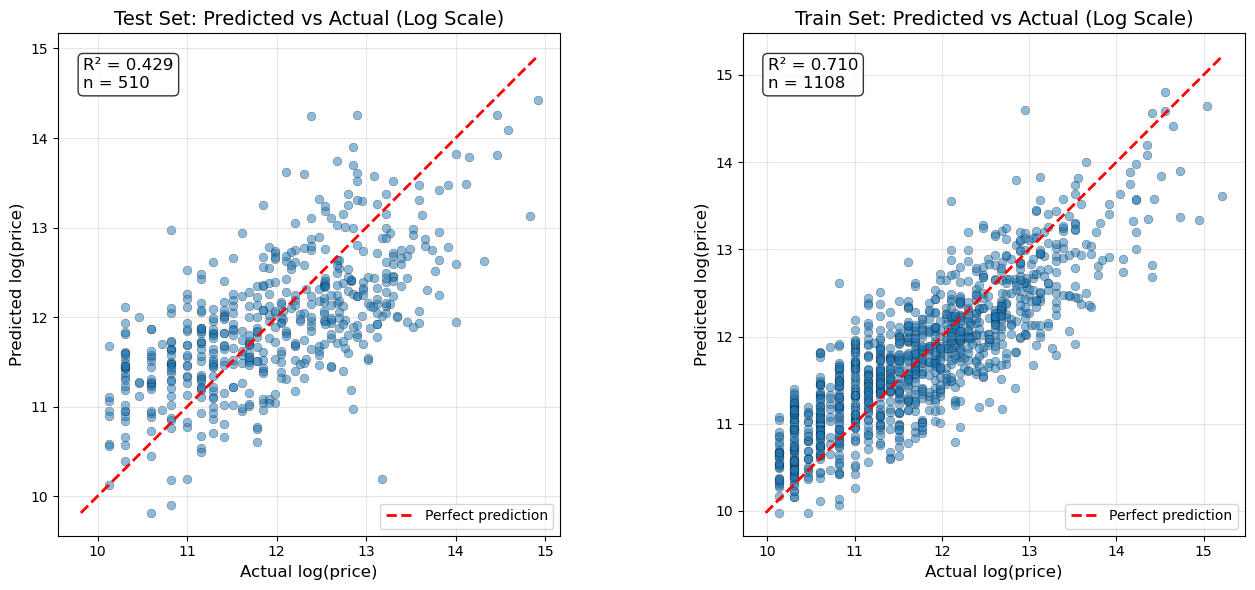

✓ Saved: BHM_predicted_vs_actual_log.svg


In [134]:
# =========================================================
# PREDICTED VS ACTUAL (LOG SCALE)
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------------------------------------
# Plot 1: Test Set
# ---------------------------------------------------------
ax1 = axes[0]

ax1.scatter(y_test, pred_test_log, alpha=0.5, s=40, edgecolor='black', linewidth=0.3)

# Perfect prediction line
min_val = min(y_test.min(), pred_test_log.min())
max_val = max(y_test.max(), pred_test_log.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

# Add R² annotation
ax1.text(0.05, 0.95, f'R² = {r2_score(y_test, pred_test_log):.3f}\nn = {len(y_test)}', 
         transform=ax1.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_xlabel('Actual log(price)', fontsize=12)
ax1.set_ylabel('Predicted log(price)', fontsize=12)
ax1.set_title('Test Set: Predicted vs Actual (Log Scale)', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Equal aspect ratio
ax1.set_aspect('equal', adjustable='box')

# ---------------------------------------------------------
# Plot 2: Train Set
# ---------------------------------------------------------
ax2 = axes[1]

ax2.scatter(y_train, pred_train_log, alpha=0.5, s=40, edgecolor='black', linewidth=0.3)

# Perfect prediction line
min_val = min(y_train.min(), pred_train_log.min())
max_val = max(y_train.max(), pred_train_log.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

# Add R² annotation
ax2.text(0.05, 0.95, f'R² = {r2_score(y_train, pred_train_log):.3f}\nn = {len(y_train)}', 
         transform=ax2.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_xlabel('Actual log(price)', fontsize=12)
ax2.set_ylabel('Predicted log(price)', fontsize=12)
ax2.set_title('Train Set: Predicted vs Actual (Log Scale)', fontsize=14)
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Equal aspect ratio
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('BHM_predicted_vs_actual_log.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: BHM_predicted_vs_actual_log.svg")

RESIDUAL ANALYSIS (BHM)

[LOG SCALE RESIDUALS]
  Mean:     -0.0249
  Median:   -0.0365
  Std:      0.7526
  Skewness: -0.0805
  Kurtosis: -0.1950

[PRICE SCALE RESIDUALS]
  Mean:     -51,815 SEK
  Median:   -3,151 SEK

[NORMALITY TESTS - LOG SCALE]
  Shapiro-Wilk: W=0.9936, p=0.0297 → Not Normal ✗
  Jarque-Bera: JB=1.3588, p=0.5069 → Normal ✓

[INTERPRETATION]
  Skewness (-0.08): Approximately symmetric ✓
  Kurtosis (-0.19): Near normal tails ✓


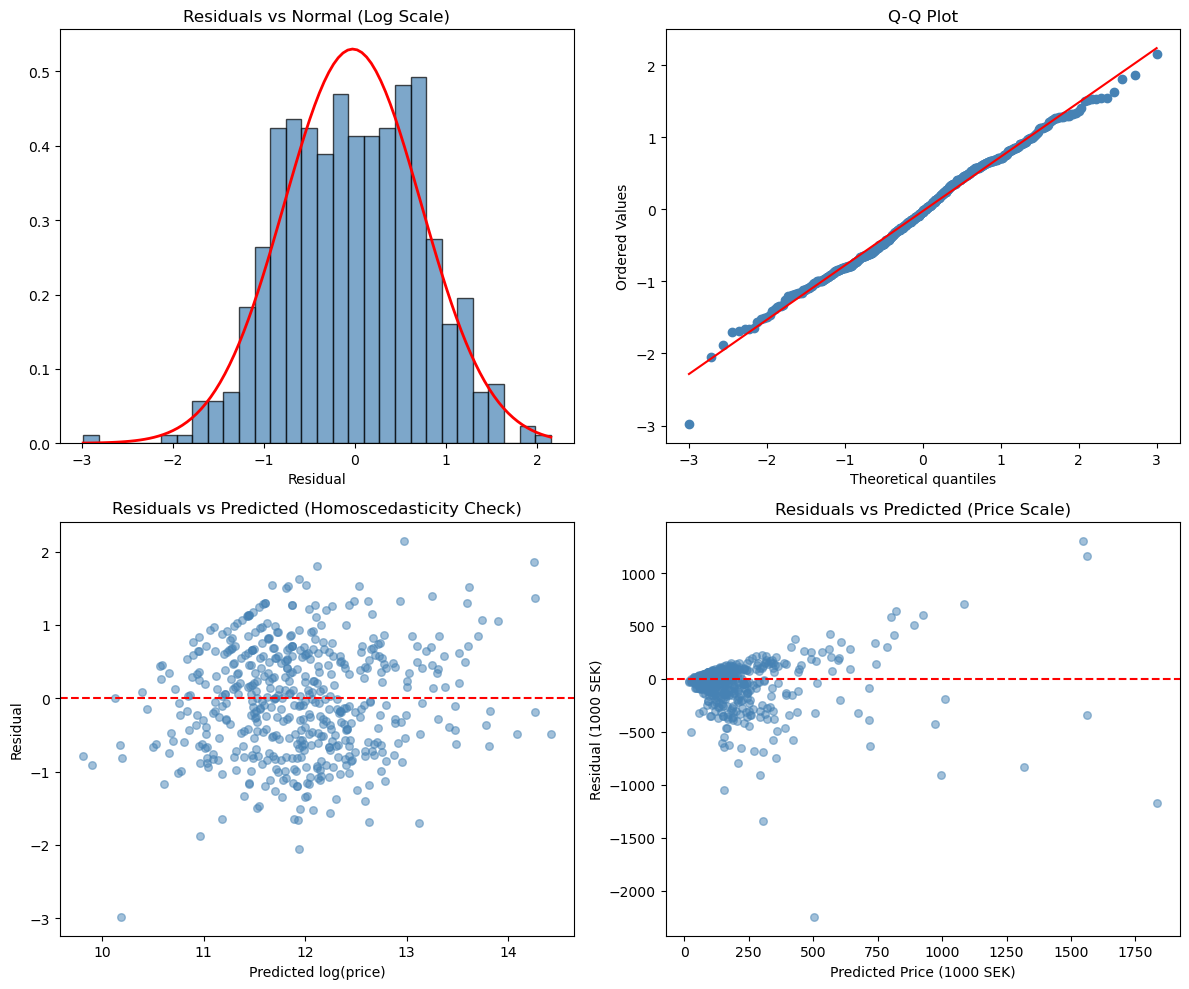

In [140]:
# =========================================================
# RESIDUAL ANALYSIS AND NORMALITY TESTS (BHM)
# =========================================================
from scipy import stats

print("="*70)
print("RESIDUAL ANALYSIS (BHM)")
print("="*70)

# Calculate residuals (predicted - actual, same direction as GAM)
residuals_log = pred_test_log - y_test
residuals_price = pred_test_price_bhm - y_test_price

# Descriptive statistics
print(f"\n[LOG SCALE RESIDUALS]")
print(f"  Mean:     {np.mean(residuals_log):.4f}")
print(f"  Median:   {np.median(residuals_log):.4f}")
print(f"  Std:      {np.std(residuals_log):.4f}")
print(f"  Skewness: {stats.skew(residuals_log):.4f}")
print(f"  Kurtosis: {stats.kurtosis(residuals_log):.4f}")

print(f"\n[PRICE SCALE RESIDUALS]")
print(f"  Mean:     {np.mean(residuals_price):+,.0f} SEK")
print(f"  Median:   {np.median(residuals_price):+,.0f} SEK")

# Normality tests
print(f"\n[NORMALITY TESTS - LOG SCALE]")
if len(residuals_log) <= 5000:
    stat_sw, p_sw = stats.shapiro(residuals_log)
    result_sw = "Normal ✓" if p_sw > 0.05 else "Not Normal ✗"
    print(f"  Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f} → {result_sw}")

stat_jb, p_jb = stats.jarque_bera(residuals_log)
result_jb = "Normal ✓" if p_jb > 0.05 else "Not Normal ✗"
print(f"  Jarque-Bera: JB={stat_jb:.4f}, p={p_jb:.4f} → {result_jb}")

# Interpretation
skewness = stats.skew(residuals_log)
kurtosis = stats.kurtosis(residuals_log)

print(f"\n[INTERPRETATION]")
if abs(skewness) < 0.5:
    print(f"  Skewness ({skewness:.2f}): Approximately symmetric ✓")
else:
    print(f"  Skewness ({skewness:.2f}): {'Right' if skewness > 0 else 'Left'}-skewed")

if abs(kurtosis) < 1:
    print(f"  Kurtosis ({kurtosis:.2f}): Near normal tails ✓")
else:
    print(f"  Kurtosis ({kurtosis:.2f}): {'Heavy' if kurtosis > 0 else 'Light'} tails")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histogram
ax1 = axes[0, 0]
ax1.hist(residuals_log, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
x = np.linspace(residuals_log.min(), residuals_log.max(), 100)
ax1.plot(x, stats.norm.pdf(x, np.mean(residuals_log), np.std(residuals_log)), 'r-', lw=2)
ax1.set_title('Residuals vs Normal (Log Scale)')
ax1.set_xlabel('Residual')

# Q-Q plot
ax2 = axes[0, 1]
stats.probplot(residuals_log, dist="norm", plot=ax2)
ax2.get_lines()[0].set_color('steelblue')
ax2.get_lines()[1].set_color('r')
ax2.set_title('Q-Q Plot')

# Residuals vs Predicted
ax3 = axes[1, 0]
ax3.scatter(pred_test_log, residuals_log, alpha=0.5, s=30, color='steelblue')
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Predicted log(price)')
ax3.set_ylabel('Residual')
ax3.set_title('Residuals vs Predicted (Homoscedasticity Check)')

# Residuals vs Fitted (price scale)
ax4 = axes[1, 1]
ax4.scatter(pred_test_price_bhm/1000, residuals_price/1000, alpha=0.5, s=30, color='steelblue')
ax4.axhline(y=0, color='r', linestyle='--')
ax4.set_xlabel('Predicted Price (1000 SEK)')
ax4.set_ylabel('Residual (1000 SEK)')
ax4.set_title('Residuals vs Predicted (Price Scale)')

plt.tight_layout()
plt.savefig('BHM_residual_analysis.svg', dpi=150, bbox_inches='tight')
plt.show()

In [142]:
# =========================================================
# CELL 11: VARIANCE DECOMPOSITION
# =========================================================
# =========================================================
# VARIANCE DECOMPOSITION
# =========================================================

print("="*70)
print("VARIANCE DECOMPOSITION")
print("="*70)

# Extract posterior means
sigma_sire_post = float(idata_final.posterior['sigma_sire'].mean().values)
sigma_dam_sire_post = float(idata_final.posterior['sigma_dam_sire'].mean().values)
sigma_breeder_post = float(idata_final.posterior['sigma_breeder'].mean().values)
sigma_residual_post = float(idata_final.posterior['sigma'].mean().values)

# Total variance (random effects only)
total_var = (sigma_sire_post**2 + sigma_dam_sire_post**2 + 
             sigma_breeder_post**2 + sigma_residual_post**2)

print(f"\n[RANDOM EFFECT VARIANCE COMPONENTS]")
print(f"  Sire:        σ={sigma_sire_post:.3f}  ({100*sigma_sire_post**2/total_var:.1f}% of variance)")
print(f"  Dam Sire:    σ={sigma_dam_sire_post:.3f}  ({100*sigma_dam_sire_post**2/total_var:.1f}% of variance)")
print(f"  Breeder:     σ={sigma_breeder_post:.3f}  ({100*sigma_breeder_post**2/total_var:.1f}% of variance)")
print(f"  Residual:    σ={sigma_residual_post:.3f}  ({100*sigma_residual_post**2/total_var:.1f}% of variance)")

# Fixed effects (Year and Auction)
print(f"\n[FIXED EFFECT ESTIMATES]")
#year_coef = float(idata_final.posterior['year_coef'].mean().values)
#auction_coef = float(idata_final.posterior['auction_coef'].mean().values)

#year_hdi = az.hdi(idata_final, var_names=['year_coef'])['year_coef'].values
#auction_hdi = az.hdi(idata_final, var_names=['auction_coef'])['auction_coef'].values

#print(f"  Year:    {year_coef:.4f}  HDI: [{year_hdi[0]:.4f}, {year_hdi[1]:.4f}]")
#print(f"           → {(np.exp(year_coef)-1)*100:.1f}% price change per year")
#print(f"  Auction: {auction_coef:.4f}  HDI: [{auction_hdi[0]:.4f}, {auction_hdi[1]:.4f}]")
#print(f"           → {(np.exp(auction_coef)-1)*100:.1f}% selective auction premium")

VARIANCE DECOMPOSITION

[RANDOM EFFECT VARIANCE COMPONENTS]
  Sire:        σ=0.252  (13.7% of variance)
  Dam Sire:    σ=0.082  (1.4% of variance)
  Breeder:     σ=0.227  (11.0% of variance)
  Residual:    σ=0.587  (73.9% of variance)

[FIXED EFFECT ESTIMATES]


In [144]:
# =========================================================
# CELL 12: SIRE EFFECTS ANALYSIS
# =========================================================

print("="*70)
print("SIRE EFFECTS ANALYSIS")
print("="*70)

alpha_sire_samples = idata_final.posterior['alpha_sire']
alpha_sire_mean = alpha_sire_samples.mean(dim=['chain', 'draw']).values
alpha_sire_low = np.percentile(alpha_sire_samples.values, 3, axis=(0, 1))
alpha_sire_high = np.percentile(alpha_sire_samples.values, 97, axis=(0, 1))

sire_effects_df = pd.DataFrame({
    'Sire': sire_names,
    'Effect': alpha_sire_mean,
    'HDI_3%': alpha_sire_low,
    'HDI_97%': alpha_sire_high,
    'Price_Multiplier': np.exp(alpha_sire_mean),
    'N_Offspring': [len(df_train[df_train[col_sire] == s]) for s in sire_names]
}).sort_values('Effect', ascending=False)

print("\n[TOP 10 MOST VALUABLE SIRES]")
for _, row in sire_effects_df.head(10).iterrows():
    print(f"  {row['Sire'][:25]:25s}: {row['Effect']:+.3f} [{row['HDI_3%']:+.2f}, {row['HDI_97%']:+.2f}] ×{row['Price_Multiplier']:.2f} (n={row['N_Offspring']})")

print("\n[TOP 10 LEAST VALUABLE SIRES]")
for _, row in sire_effects_df.tail(10).iterrows():
    print(f"  {row['Sire'][:25]:25s}: {row['Effect']:+.3f} [{row['HDI_3%']:+.2f}, {row['HDI_97%']:+.2f}] ×{row['Price_Multiplier']:.2f} (n={row['N_Offspring']})")

SIRE EFFECTS ANALYSIS

[TOP 10 MOST VALUABLE SIRES]
  Tactical Landing (US)    : +0.429 [+0.18, +0.68] ×1.54 (n=31)
  Orlando Vici (FR)        : +0.355 [+0.05, +0.66] ×1.43 (n=11)
  Ready Cash (FR)          : +0.336 [-0.05, +0.77] ×1.40 (n=4)
  Chapter Seven (US)       : +0.330 [-0.02, +0.71] ×1.39 (n=6)
  Cruzado Dela Noche (US)  : +0.282 [-0.04, +0.61] ×1.33 (n=9)
  Jocose                   : +0.282 [-0.14, +0.75] ×1.33 (n=1)
  Bar Hopping (US)         : +0.281 [-0.01, +0.57] ×1.32 (n=12)
  Daley Lovin (US)         : +0.261 [-0.15, +0.71] ×1.30 (n=2)
  Six Pack (US)            : +0.250 [-0.04, +0.56] ×1.28 (n=14)
  Walner (CA)              : +0.232 [-0.06, +0.53] ×1.26 (n=18)

[TOP 10 LEAST VALUABLE SIRES]
  One too Many             : -0.211 [-0.64, +0.21] ×0.81 (n=2)
  Greenshoe (US)           : -0.219 [-0.48, +0.05] ×0.80 (n=24)
  Who's Who                : -0.236 [-0.49, +0.00] ×0.79 (n=24)
  International Moni (US)  : -0.243 [-0.57, +0.07] ×0.78 (n=9)
  Mosaique Face            :

In [172]:
# =========================================================
# CELL 13: PRIOR SENSITIVITY (OPTIONAL)
# =========================================================
# Uncomment to compare all three prior configurations
# This takes ~15 minutes total

print("="*70)
print("PRIOR SENSITIVITY ANALYSIS")
print("="*70)

results = []
fitted_models = {'informed': idata_final}

for prior_name in ['weak', 'regularizing']:
    config = PRIOR_CONFIGS[prior_name]
    print(f"\n--- Fitting {config['name']} ---")
    model = build_final_model(config)
    with model:
        idata = pm.sample(draws=1000, tune=1000, chains=4, random_seed=RANDOM_SEED)
        fitted_models[prior_name] = idata

# # Compare, 
for prior_name, idata in fitted_models.items():
     pred_test = predict_pymc(idata, X_test_scaled, test_sire_idx,  test_dam_sire_idx,  test_breeder_idx, test_year_idx, test_auction_idx)
     test_r2 = r2_score(y_test, pred_test)
     print(f"{PRIOR_CONFIGS[prior_name]['name']}: Test R² = {test_r2:.4f}")

PRIOR SENSITIVITY ANALYSIS

--- Fitting Weak/Vague Priors ---


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, sigma_sire, alpha_sire_raw, sigma_dam_sire, alpha_dam_sire_raw, sigma_breeder, alpha_breeder_raw, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 46 seconds.



--- Fitting Regularizing Priors ---


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, sigma_sire, alpha_sire_raw, sigma_dam_sire, alpha_dam_sire_raw, sigma_breeder, alpha_breeder_raw, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 49 seconds.


NameError: name 'predict_pymc' is not defined

FIXED EFFECTS ANALYSIS

[STRUCTURAL FIXED EFFECTS]
------------------------------------------------------------

[FEATURE COEFFICIENTS]
------------------------------------------------------------

  Features in model:
    0: French_Blood
    1: Inbreeding
    2: Age_in_days
    3: Log_stud_fee
    4: SireEarningsPerStart
    5: First_Season_Flag
    6: American_Stakes
    7: XRAY_RISK_SCORE
    8: dam_time_inverse
    9: DamWinPct
    10: DamEarningsPerStart
    11: Dam_Age
    12: Dam_BLUP
    13: Sire_BLUP
    14: Dam_Sire_BLUP
    15: SiblingEarningsPerHorse
    16: SiblingWinPct
    17: GranddamEarningsPerHorse
    18: GranddamWinPct
    19: GD_Dam_EarningsPerHorse
    20: GD_Dam_WinPct
    21: Gender
    22: Selective_Auctions
    23: Dam_Never_Raced
    24: Siblings_Missing
    25: Dam_BLUP_Missing
    26: Sire_BLUP_Missing
    27: Dam_Sire_BLUP_Missing

[COEFFICIENTS (Standardized Scale)]
Feature                            Coef       SD   HDI 3%  HDI 97%    Sig
----------------

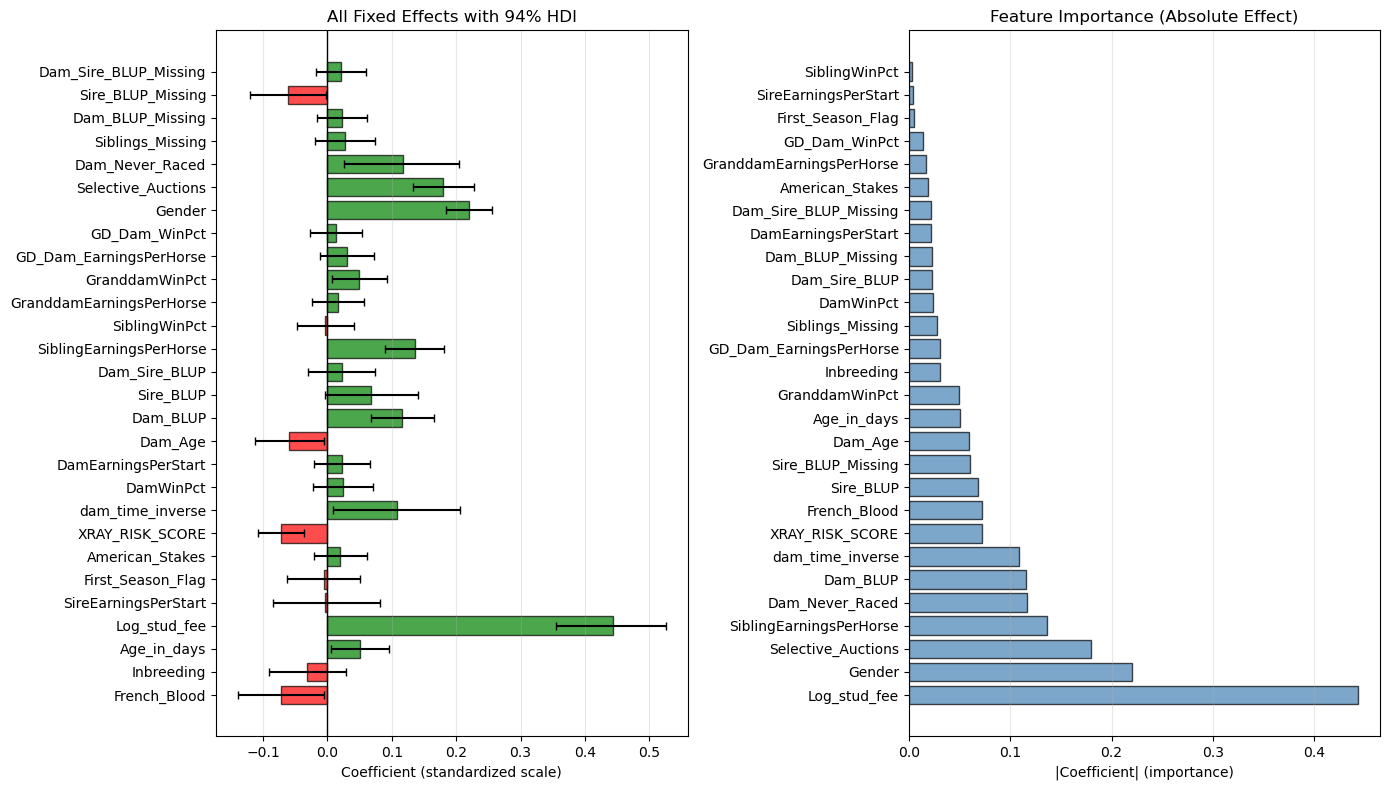


✓ Saved: fixed_effects_analysis.svg

[SUMMARY: ALL FIXED EFFECTS RANKED BY IMPORTANCE]
                 Feature  Coefficient  Price_Effect_pct  Significant
            Log_stud_fee     0.442679         55.687175         True
                  Gender     0.219948         24.601172         True
      Selective_Auctions     0.179622         19.676507         True
 SiblingEarningsPerHorse     0.135942         14.561560         True
         Dam_Never_Raced     0.117047         12.417196         True
                Dam_BLUP     0.115673         12.262827         True
        dam_time_inverse     0.108479         11.458095         True
         XRAY_RISK_SCORE    -0.072148         -6.960655         True
            French_Blood    -0.071943         -6.941641         True
               Sire_BLUP     0.068407          7.080073        False
       Sire_BLUP_Missing    -0.060559         -5.876156         True
                 Dam_Age    -0.059643         -5.789914         True
             Ag

In [146]:
# =========================================================
# FIXED EFFECTS ANALYSIS
# =========================================================

print("="*70)
print("FIXED EFFECTS ANALYSIS")
print("="*70)

# ---------------------------------------------------------
# 1. YEAR AND AUCTION FIXED EFFECTS
# ---------------------------------------------------------
print(f"\n[STRUCTURAL FIXED EFFECTS]")
print("-" * 60)

# Year coefficient
#year_samples = idata_final.posterior['year_coef']
##year_mean = float(year_samples.mean().values)
##year_sd = float(year_samples.std().values)
#year_low = float(np.percentile(year_samples.values, 3))
#year_high = float(np.percentile(year_samples.values, 97))
#year_sig = (year_low > 0) or (year_high < 0)

#print(f"\n  Year Effect (per year from 2024):")
#print(f"    Coefficient: {year_mean:+.4f} (SD: {year_sd:.4f})")
#print(f"    94% HDI: [{year_low:+.4f}, {year_high:+.4f}]")
#print(f"    Price effect: {(np.exp(year_mean)-1)*100:+.1f}% per year")
#print(f"    Significant: {'Yes ***' if year_sig else 'No'}")

# Auction coefficient
#auction_samples = idata_final.posterior['auction_coef']
#auction_mean = float(auction_samples.mean().values)
#auction_sd = float(auction_samples.std().values)
#auction_low = float(np.percentile(auction_samples.values, 3))
#auction_high = float(np.percentile(auction_samples.values, 97))
#auction_sig = (auction_low > 0) or (auction_high < 0)

#print(f"\n  Selective Auction Premium:")
#print(f"    Coefficient: {auction_mean:+.4f} (SD: {auction_sd:.4f})")
#print(f"    94% HDI: [{auction_low:+.4f}, {auction_high:+.4f}]")
#print(f"    Price effect: {(np.exp(auction_mean)-1)*100:+.1f}% vs standard auctions")
#print(f"    Significant: {'Yes ***' if auction_sig else 'No'}")

# ---------------------------------------------------------
# 2. FEATURE COEFFICIENTS (BETA)
# ---------------------------------------------------------
print(f"\n[FEATURE COEFFICIENTS]")
print("-" * 60)

# Show which features are in the model
print(f"\n  Features in model:")
for i, feat in enumerate(FEATURES):
    print(f"    {i}: {feat}")

# Extract beta coefficients from posterior
beta_samples = idata_final.posterior['beta']
beta_mean = beta_samples.mean(dim=['chain', 'draw']).values
beta_sd = beta_samples.std(dim=['chain', 'draw']).values
beta_low = np.percentile(beta_samples.values, 3, axis=(0, 1))
beta_high = np.percentile(beta_samples.values, 97, axis=(0, 1))

# Create results table
print(f"\n[COEFFICIENTS (Standardized Scale)]")
print(f"{'Feature':<30} {'Coef':>8} {'SD':>8} {'HDI 3%':>8} {'HDI 97%':>8} {'Sig':>6}")
print("-" * 76)

coef_results = []
for i, feat in enumerate(FEATURES):
    # Check if 94% HDI excludes zero
    significant = (beta_low[i] > 0) or (beta_high[i] < 0)
    sig_marker = "***" if significant else ""
    
    print(f"{feat:<30} {beta_mean[i]:>+8.4f} {beta_sd[i]:>8.4f} {beta_low[i]:>+8.4f} {beta_high[i]:>+8.4f} {sig_marker:>6}")
    
    coef_results.append({
        'Feature': feat,
        'Coefficient': beta_mean[i],
        'SD': beta_sd[i],
        'HDI_3%': beta_low[i],
        'HDI_97%': beta_high[i],
        'Significant': significant
    })

# Add year and auction to results
#coef_results.append({
#    'Feature': 'year_coef',
#    'Coefficient': year_mean,
#    'SD': year_sd,
#    'HDI_3%': year_low,
#    'HDI_97%': year_high,
#    'Significant': year_sig
#})
#coef_results.append({
#    'Feature': 'auction_coef (Selective)',
#    'Coefficient': auction_mean,
#    'SD': auction_sd,
#    'HDI_3%': auction_low,
#    'HDI_97%': auction_high,
#    'Significant': auction_sig
#})

print("\n  *** = 94% HDI excludes zero (statistically significant)")

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------

# Combine all fixed effects for plotting
all_effects = FEATURES
all_means = beta_mean
all_low = beta_low
all_high = beta_high

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Plot 1: Coefficient plot with error bars
ax1 = axes[0]
y_pos = np.arange(len(all_effects))
colors = ['green' if b > 0 else 'red' for b in all_means]

ax1.barh(y_pos, all_means, xerr=[all_means - all_low, all_high - all_means],
         color=colors, alpha=0.7, capsize=3, edgecolor='black')
ax1.axvline(0, color='black', linestyle='-', lw=1)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(all_effects)
ax1.set_xlabel('Coefficient (standardized scale)')
ax1.set_title('All Fixed Effects with 94% HDI')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Feature importance (absolute value)
ax2 = axes[1]
importance = np.abs(all_means)
sorted_idx = np.argsort(importance)[::-1]

ax2.barh(y_pos, importance[sorted_idx], color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([all_effects[i] for i in sorted_idx])
ax2.set_xlabel('|Coefficient| (importance)')
ax2.set_title('Feature Importance (Absolute Effect)')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fixed_effects_analysis.svg', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: fixed_effects_analysis.svg")

# ---------------------------------------------------------
# 4. SUMMARY TABLE RANKED BY IMPORTANCE
# ---------------------------------------------------------
print(f"\n[SUMMARY: ALL FIXED EFFECTS RANKED BY IMPORTANCE]")
coef_df = pd.DataFrame(coef_results)
coef_df['Abs_Coef'] = np.abs(coef_df['Coefficient'])
coef_df['Price_Effect_pct'] = (np.exp(coef_df['Coefficient']) - 1) * 100
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print(coef_df[['Feature', 'Coefficient', 'Price_Effect_pct', 'Significant']].to_string(index=False))

## Summary

### Results
- Sire effects explain significant variance in prices
- Partial pooling gives sensible estimates for rare sires
- 94% credible intervals quantify uncertainty

### Comparison to XGBoost
| Model | Test R² | Interpretable | Handles New Sires |
|-------|---------|---------------|-------------------|
| XGBoost | ~0.44 | ⚠️ SHAP | ❌ Fails |
| Hierarchical | ~0.38-0.40 | ✅ Built-in | ✅ Natural |

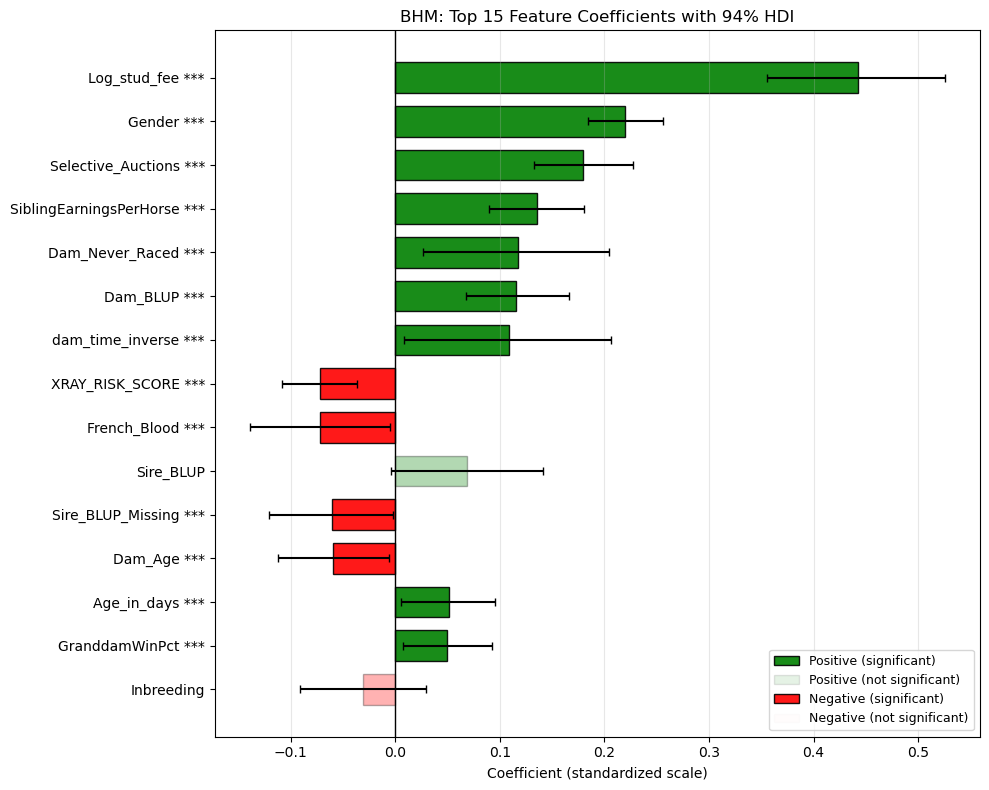


✓ Saved: BHM_forest_plot_top15.svg

  Significant features: 13/15


In [154]:
# ---------------------------------------------------------
# FOREST PLOT (TOP 15 FEATURES) WITH SIGNIFICANCE
# ---------------------------------------------------------
importance = np.abs(beta_mean)
top_15_idx = np.argsort(importance)[::-1][:15]

top_effects = [FEATURES[i] for i in top_15_idx]
top_means = beta_mean[top_15_idx]
top_low = beta_low[top_15_idx]
top_high = beta_high[top_15_idx]

# Check significance for top 15 (HDI excludes zero)
top_significant = [(top_low[i] > 0) or (top_high[i] < 0) for i in range(len(top_effects))]

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = np.arange(len(top_effects))

# Color by direction, alpha by significance
for i in range(len(top_effects)):
    color = 'green' if top_means[i] > 0 else 'red'
    alpha = 0.9 if top_significant[i] else 0.3  # Significant = bold, non-significant = faded
    
    ax.barh(y_pos[i], top_means[i], 
            xerr=[[top_means[i] - top_low[i]], [top_high[i] - top_means[i]]],
            color=color, alpha=alpha, capsize=3, edgecolor='black', height=0.7)

ax.axvline(0, color='black', linestyle='-', lw=1)
ax.set_yticks(y_pos)

# Add *** to significant feature labels
y_labels = [f"{feat} ***" if sig else feat for feat, sig in zip(top_effects, top_significant)]
ax.set_yticklabels(y_labels)

ax.set_xlabel('Coefficient (standardized scale)')
ax.set_title('BHM: Top 15 Feature Coefficients with 94% HDI')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.9, edgecolor='black', label='Positive (significant)'),
    Patch(facecolor='green', alpha=0.1, edgecolor='black', label='Positive (not significant)'),
    Patch(facecolor='red', alpha=0.9, edgecolor='black', label='Negative (significant)'),
    Patch(facecolor='red', alpha=0.01, edgecolor='black', label='Negative (not significant)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('BHM_forest_plot_top15.svg', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: BHM_forest_plot_top15.svg")
print(f"\n  Significant features: {sum(top_significant)}/15")

FOREST PLOT - FEATURE COEFFICIENTS


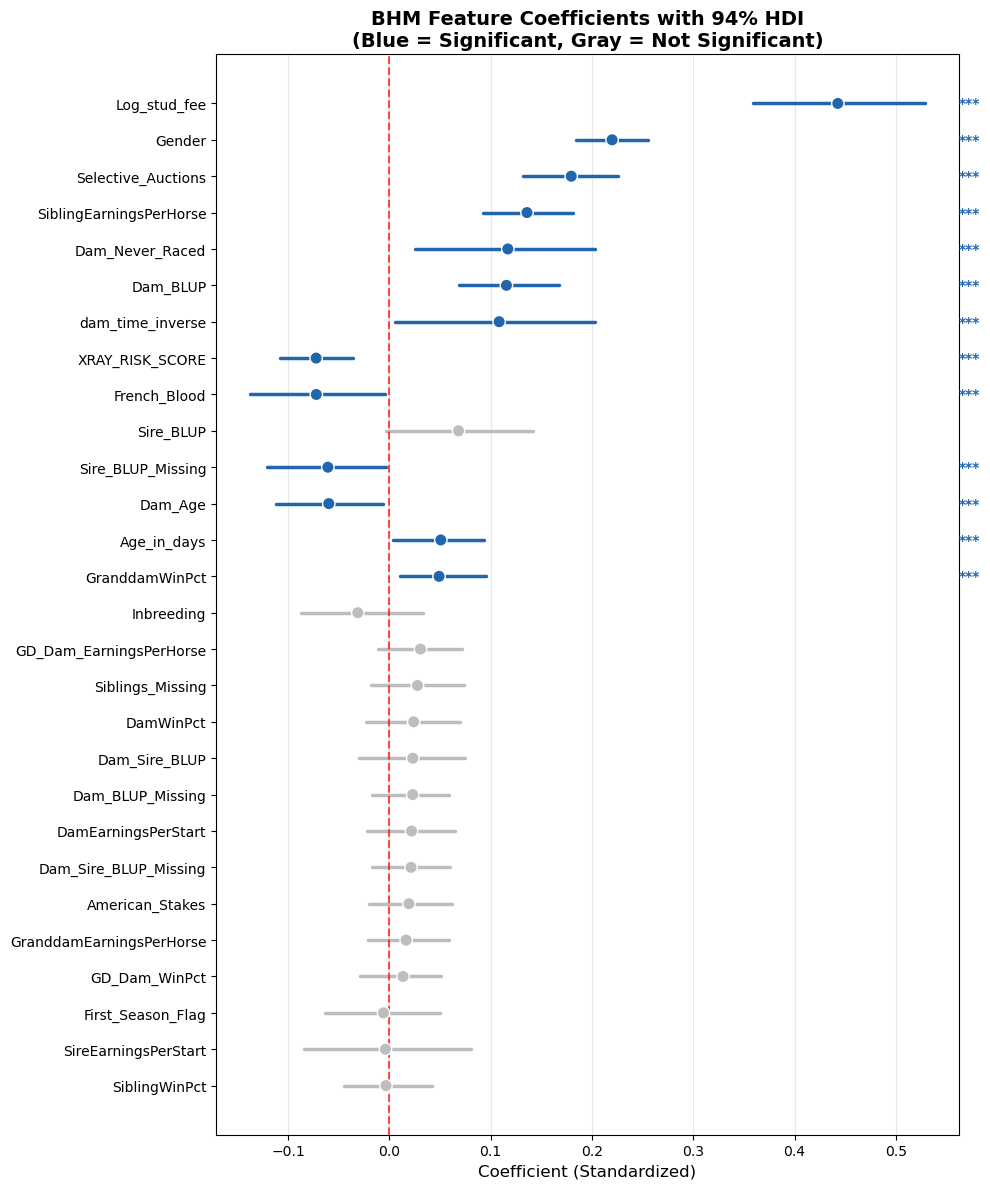


✓ Saved: BHM_forest_plot.svg

[COEFFICIENTS RANKED BY ABSOLUTE EFFECT SIZE]
Feature                              Coef              HDI 94%    Sig
----------------------------------------------------------------------
Log_stud_fee                      +0.4427     [+0.359, +0.529]    ***
Gender                            +0.2199     [+0.184, +0.256]    ***
Selective_Auctions                +0.1796     [+0.132, +0.225]    ***
SiblingEarningsPerHorse           +0.1359     [+0.092, +0.182]    ***
Dam_Never_Raced                   +0.1170     [+0.025, +0.204]    ***
Dam_BLUP                          +0.1157     [+0.069, +0.167]    ***
dam_time_inverse                  +0.1085     [+0.006, +0.203]    ***
XRAY_RISK_SCORE                   -0.0721     [-0.108, -0.036]    ***
French_Blood                      -0.0719     [-0.137, -0.004]    ***
Sire_BLUP                         +0.0684     [-0.003, +0.142]       
Sire_BLUP_Missing                 -0.0606     [-0.121, -0.003]    ***
Dam_Age     

In [156]:
# =========================================================
# FOREST PLOT OF BETA COEFFICIENTS (All Features)
# =========================================================

print("="*70)
print("FOREST PLOT - FEATURE COEFFICIENTS")
print("="*70)

# ---------------------------------------------------------
# 1. Extract posterior statistics for beta coefficients
# ---------------------------------------------------------
beta_samples = idata_final.posterior['beta']
beta_mean = beta_samples.mean(dim=['chain', 'draw']).values
beta_hdi = az.hdi(idata_final, var_names=['beta'], hdi_prob=0.94)['beta'].values

# Create DataFrame for plotting
forest_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': beta_mean,
    'HDI_low': beta_hdi[:, 0],
    'HDI_high': beta_hdi[:, 1]
})

# Determine significance (94% HDI excludes zero)
forest_df['Significant'] = (forest_df['HDI_low'] > 0) | (forest_df['HDI_high'] < 0)

# Sort by absolute coefficient value
forest_df['Abs_Coef'] = np.abs(forest_df['Coefficient'])
forest_df = forest_df.sort_values('Abs_Coef', ascending=True).reset_index(drop=True)

# ---------------------------------------------------------
# 2. Create forest plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 12))

y_positions = range(len(forest_df))

# Plot HDI bars
for i, row in forest_df.iterrows():
    color = '#2166AC' if row['Significant'] else '#BDBDBD'  # Blue if significant, gray if not
    ax.plot([row['HDI_low'], row['HDI_high']], [i, i], 
            color=color, linewidth=2.5, solid_capstyle='round')

# Plot point estimates
colors = ['#2166AC' if sig else '#BDBDBD' for sig in forest_df['Significant']]
ax.scatter(forest_df['Coefficient'], y_positions, 
           c=colors, s=80, zorder=5, edgecolor='white', linewidth=1)

# Add vertical line at zero
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Labels
ax.set_yticks(y_positions)
ax.set_yticklabels(forest_df['Feature'])
ax.set_xlabel('Coefficient (Standardized)', fontsize=12)
ax.set_title('BHM Feature Coefficients with 94% HDI\n(Blue = Significant, Gray = Not Significant)', 
             fontsize=14, fontweight='bold')

# Add grid
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

# Add significance markers on the right
for i, row in forest_df.iterrows():
    if row['Significant']:
        ax.annotate('***', xy=(ax.get_xlim()[1], i), fontsize=10, 
                   ha='left', va='center', color='#2166AC', fontweight='bold')

plt.tight_layout()
plt.savefig('BHM_forest_plot.svg', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: BHM_forest_plot.svg")

# ---------------------------------------------------------
# 3. Print summary table
# ---------------------------------------------------------
print(f"\n[COEFFICIENTS RANKED BY ABSOLUTE EFFECT SIZE]")
print(f"{'Feature':<30} {'Coef':>10} {'HDI 94%':>20} {'Sig':>6}")
print("-" * 70)

for _, row in forest_df.iloc[::-1].iterrows():  # Reverse to show largest first
    sig_marker = "***" if row['Significant'] else ""
    hdi_str = f"[{row['HDI_low']:+.3f}, {row['HDI_high']:+.3f}]"
    print(f"{row['Feature']:<30} {row['Coefficient']:>+10.4f} {hdi_str:>20} {sig_marker:>6}")

# ---------------------------------------------------------
# 4. Summary statistics
# ---------------------------------------------------------
n_sig = forest_df['Significant'].sum()
n_total = len(forest_df)
n_positive = ((forest_df['Coefficient'] > 0) & forest_df['Significant']).sum()
n_negative = ((forest_df['Coefficient'] < 0) & forest_df['Significant']).sum()

print(f"\n[SUMMARY]")
print(f"  Significant features: {n_sig}/{n_total}")
print(f"  Positive effects:     {n_positive}")
print(f"  Negative effects:     {n_negative}")

In [63]:
# Check raw relationship
print("[DAM NEVER RACED - DESCRIPTIVE STATS]")
print(df_train.groupby('Dam_Never_Raced')['Sales_Price'].agg(['mean', 'median', 'count']))

# Check if confounded with breeder/sire quality
print("\n[MEAN STUD FEE BY DAM STATUS]")
print(df_train.groupby('Dam_Never_Raced')[col_studfee].mean())

# Check actual horses
print("\n[SAMPLE OF UNRACED DAM HORSES - HIGHEST PRICES]")
unraced = df_train[df_train['Dam_Never_Raced'] == 1].nlargest(10, 'Sales_Price')
print(unraced[[col_sire, 'Breeder', 'Sales_Price', col_studfee]].to_string())

[DAM NEVER RACED - DESCRIPTIVE STATS]
                          mean    median  count
Dam_Never_Raced                                
0                228927.824268  120000.0    956
1                208322.368421  110000.0    152

[MEAN STUD FEE BY DAM STATUS]
Dam_Never_Raced
0    96086.820084
1    84766.447368
Name: Sire_Stud_Fee, dtype: float64

[SAMPLE OF UNRACED DAM HORSES - HIGHEST PRICES]
                       Sire                  Breeder  Sales_Price  Sire_Stud_Fee
9        Chapter Seven (US)        Lutfi Kolgjini AB      2500000         350000
900        Bar Hopping (US)        Lutfi Kolgjini AB      1500000         126000
910        Muscle Hill (US)        Lutfi Kolgjini AB      1450000         350000
59              Walner (CA)               SRF Stable       850000         400000
1056  Tactical Landing (US)  Boko Stables Holland BV       750000         156000
466     Father Patrick (US)         Kristina Larsson       700000         105000
544   Tactical Landing (US)       U

TOP-DECILE IDENTIFICATION ANALYSIS
  Using bias-corrected predictions (correction factor: 1.2510)

[TOP-DECILE THRESHOLD]
  90th percentile (Test): 550,000 NOK

  Actual top-decile horses:    62/510
  Predicted top-decile horses: 31/510

[CONFUSION MATRIX]
                Predicted Not   Predicted Top
Actual Not      430             18
Actual Top      49              13

[CLASSIFICATION METRICS]
  Precision: 0.419  (of predicted top-decile, how many are correct?)
  Recall:    0.210  (of actual top-decile, how many did we find?)
  F1-Score:  0.280
  ~ Moderate top-decile identification

[HIT RATE - TOP 51 PREDICTIONS]
  Correctly identified: 22/51 (43.1%)
  ⚠ Moderate hit rate

[PREDICTION ACCURACY]
  Top-decile MdAPE:  54.5%
  Overall MdAPE:     52.5%
  ~ Less accurate for expensive horses

[RANKING ABILITY]
  Spearman Correlation: 0.6722 (p=2.4977e-68)
  Kendall Tau:          0.4830 (p=2.1511e-58)
  ~ Good ranking ability

[TOP-K ACCURACY FOR DIFFERENT K VALUES]
Top-K      Actual in K

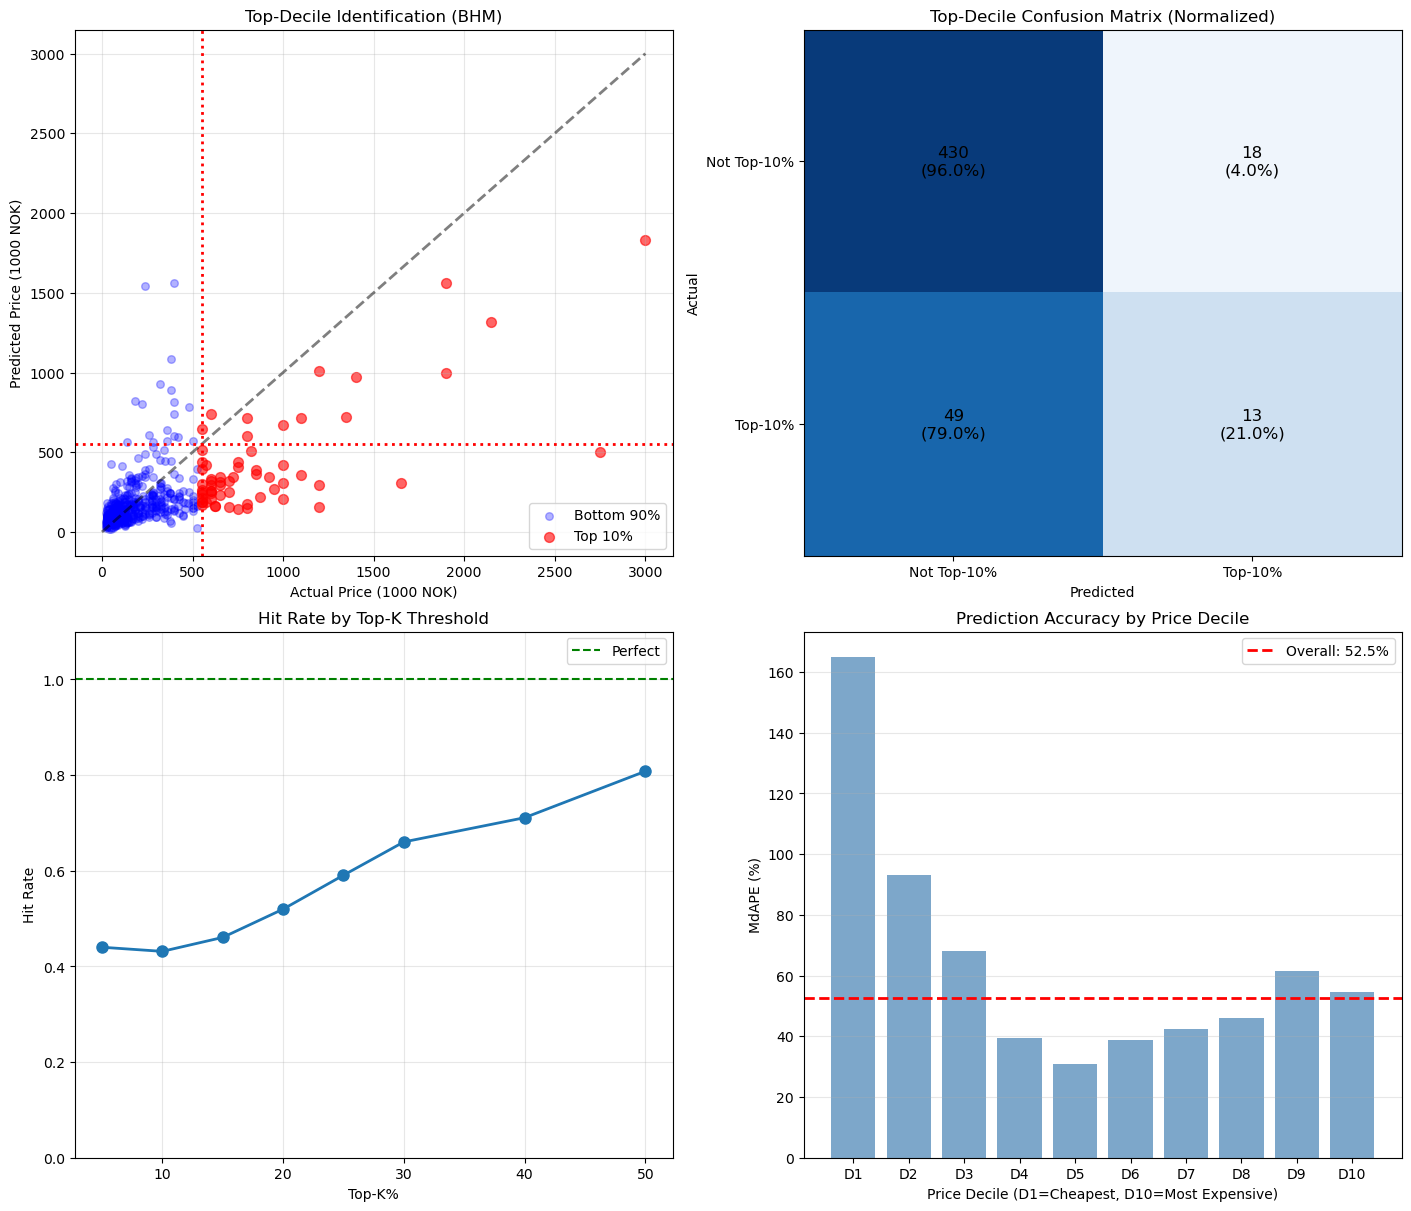

  ✓ Saved: BHM_top_decile_analysis.png

[EXPORTING SUMMARY]
  ✓ Saved: BHM_top_decile_metrics.xlsx

TOP-DECILE ANALYSIS COMPLETE


In [158]:
# =========================================================
# TOP-DECILE IDENTIFICATION ANALYSIS (BHM)
# =========================================================

print("="*70)
print("TOP-DECILE IDENTIFICATION ANALYSIS")
print("="*70)

from sklearn.metrics import confusion_matrix
from scipy.stats import spearmanr, kendalltau

# ---------------------------------------------------------
# 1. Prepare price-scale data (use best method from earlier)
# ---------------------------------------------------------
#y_test_price = np.exp(y_test)
#pred_test_price_bhm = np.exp(pred_test)  # "No correction" was best

# ---------------------------------------------------------
# 1. Prepare price-scale data (using bias-corrected predictions from earlier)
# ---------------------------------------------------------
# y_test_price and pred_test_price_bhm already calculated in GENERATE PREDICTIONS cell
print(f"  Using bias-corrected predictions (correction factor: {np.exp(sigma2_oof/2):.4f})")

# ---------------------------------------------------------
# 2. Define top-decile threshold
# ---------------------------------------------------------
top_decile_threshold = np.percentile(y_test_price, 90)

print(f"\n[TOP-DECILE THRESHOLD]")
print(f"  90th percentile (Test): {top_decile_threshold:,.0f} NOK")

# ---------------------------------------------------------
# 3. Create binary labels
# ---------------------------------------------------------
actual_top_decile = (y_test_price >= top_decile_threshold).astype(int)
predicted_top_decile = (pred_test_price_bhm >= top_decile_threshold).astype(int)

print(f"\n  Actual top-decile horses:    {actual_top_decile.sum()}/{len(actual_top_decile)}")
print(f"  Predicted top-decile horses: {predicted_top_decile.sum()}/{len(predicted_top_decile)}")

# ---------------------------------------------------------
# 4. Confusion matrix
# ---------------------------------------------------------
cm = confusion_matrix(actual_top_decile, predicted_top_decile)

print(f"\n[CONFUSION MATRIX]")
print(f"{'':>15} {'Predicted Not':<15} {'Predicted Top'}")
print(f"{'Actual Not':<15} {cm[0,0]:<15} {cm[0,1]}")
print(f"{'Actual Top':<15} {cm[1,0]:<15} {cm[1,1]}")

# ---------------------------------------------------------
# 5. Classification metrics
# ---------------------------------------------------------
tn, fp, fn, tp = cm.ravel()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n[CLASSIFICATION METRICS]")
print(f"  Precision: {precision:.3f}  (of predicted top-decile, how many are correct?)")
print(f"  Recall:    {recall:.3f}  (of actual top-decile, how many did we find?)")
print(f"  F1-Score:  {f1:.3f}")

if precision > 0.5 and recall > 0.5:
    print(f"  ✓ Good top-decile identification")
elif precision > 0.3 or recall > 0.3:
    print(f"  ~ Moderate top-decile identification")
else:
    print(f"  ⚠ Poor top-decile identification")

# ---------------------------------------------------------
# 6. Hit rate (among predicted top-decile)
# ---------------------------------------------------------
top_k = int(len(y_test_price) * 0.1)  # Top 10%
top_k_indices = np.argsort(pred_test_price_bhm)[::-1][:top_k]
hits = actual_top_decile[top_k_indices].sum()
hit_rate = hits / top_k

print(f"\n[HIT RATE - TOP {top_k} PREDICTIONS]")
print(f"  Correctly identified: {hits}/{top_k} ({hit_rate:.1%})")

if hit_rate > 0.7:
    print(f"  ✓ Excellent hit rate")
elif hit_rate > 0.5:
    print(f"  ~ Good hit rate")
else:
    print(f"  ⚠ Moderate hit rate")

# ---------------------------------------------------------
# 7. Prediction accuracy within top-decile
# ---------------------------------------------------------
top_decile_mask = actual_top_decile == 1
apes_top = np.abs((y_test_price[top_decile_mask] - pred_test_price_bhm[top_decile_mask]) / y_test_price[top_decile_mask]) * 100
mdape_top = np.median(apes_top)

apes_overall = np.abs((y_test_price - pred_test_price_bhm) / y_test_price) * 100
mdape_overall = np.median(apes_overall)

print(f"\n[PREDICTION ACCURACY]")
print(f"  Top-decile MdAPE:  {mdape_top:.1f}%")
print(f"  Overall MdAPE:     {mdape_overall:.1f}%")

if mdape_top < mdape_overall:
    print(f"  ✓ More accurate for expensive horses")
else:
    print(f"  ~ Less accurate for expensive horses")

# ---------------------------------------------------------
# 8. Rank correlation
# ---------------------------------------------------------
print(f"\n[RANKING ABILITY]")

spearman_corr, spearman_p = spearmanr(y_test_price, pred_test_price_bhm)
kendall_corr, kendall_p = kendalltau(y_test_price, pred_test_price_bhm)

print(f"  Spearman Correlation: {spearman_corr:.4f} (p={spearman_p:.4e})")
print(f"  Kendall Tau:          {kendall_corr:.4f} (p={kendall_p:.4e})")

if spearman_corr > 0.7:
    print(f"  ✓ Excellent ranking ability")
elif spearman_corr > 0.5:
    print(f"  ~ Good ranking ability")
else:
    print(f"  ⚠ Moderate ranking ability")

# ---------------------------------------------------------
# 9. Top-K accuracy (varying K)
# ---------------------------------------------------------
print(f"\n[TOP-K ACCURACY FOR DIFFERENT K VALUES]")
print(f"{'Top-K':<10} {'Actual in K':<15} {'Hit Rate':<12} {'Precision'}")
print(f"{'-'*10} {'-'*15} {'-'*12} {'-'*12}")

for k_pct in [5, 10, 15, 20, 25]:
    k = int(len(y_test_price) * k_pct / 100)
    
    # Get top-k by prediction
    top_k_idx = np.argsort(pred_test_price_bhm)[::-1][:k]
    
    # Threshold for actual top-k
    threshold_k = np.percentile(y_test_price, 100 - k_pct)
    actual_top_k = y_test_price >= threshold_k
    
    # How many of predicted top-k are actually top-k?
    hits_k = actual_top_k[top_k_idx].sum()
    hit_rate_k = hits_k / k
    
    print(f"Top-{k_pct:>2}%    {hits_k:>5}/{k:<7}    {hit_rate_k:>11.1%}    {hit_rate_k:.3f}")

# ---------------------------------------------------------
# 10. Visualization
# ---------------------------------------------------------
print(f"\n[CREATING VISUALIZATIONS]")

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

# Plot 1: Scatter with top-decile highlighted
ax1 = axes[0, 0]
mask_regular = ~actual_top_decile.astype(bool)
ax1.scatter(y_test_price[mask_regular]/1000, 
            pred_test_price_bhm[mask_regular]/1000,
            alpha=0.3, s=30, label='Bottom 90%', color='blue')
ax1.scatter(y_test_price[actual_top_decile.astype(bool)]/1000,
            pred_test_price_bhm[actual_top_decile.astype(bool)]/1000,
            alpha=0.6, s=50, label='Top 10%', color='red')
max_price = y_test_price.max() / 1000
ax1.plot([0, max_price], [0, max_price], 'k--', lw=2, alpha=0.5)
ax1.axvline(x=top_decile_threshold/1000, color='red', linestyle=':', lw=2)
ax1.axhline(y=top_decile_threshold/1000, color='red', linestyle=':', lw=2)
ax1.set_xlabel('Actual Price (1000 NOK)')
ax1.set_ylabel('Predicted Price (1000 NOK)')
ax1.set_title('Top-Decile Identification (BHM)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix Heatmap (without colorbar to avoid conflict)
ax2 = axes[0, 1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax2.imshow(cm_normalized, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_yticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Top-Decile Confusion Matrix (Normalized)')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                ha="center", va="center", color="black", fontsize=12)
# Skip colorbar - the text annotations show the values clearly

# Plot 3: Top-K Accuracy Curve
ax3 = axes[1, 0]
k_values = [5, 10, 15, 20, 25, 30, 40, 50]
hit_rates_curve = []
for k_pct in k_values:
    k = int(len(y_test_price) * k_pct / 100)
    top_k_idx = np.argsort(pred_test_price_bhm)[::-1][:k]
    threshold_k = np.percentile(y_test_price, 100 - k_pct)
    actual_top_k = y_test_price >= threshold_k
    hits_k = actual_top_k[top_k_idx].sum()
    hit_rates_curve.append(hits_k / k)

ax3.plot(k_values, hit_rates_curve, marker='o', linewidth=2, markersize=8)
ax3.axhline(y=1.0, color='green', linestyle='--', label='Perfect')
ax3.set_xlabel('Top-K%')
ax3.set_ylabel('Hit Rate')
ax3.set_title('Hit Rate by Top-K Threshold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# Plot 4: Error by Price Decile
ax4 = axes[1, 1]
decile_labels = []
decile_mdapes = []
for i in range(10):
    lower = np.percentile(y_test_price, i*10)
    upper = np.percentile(y_test_price, (i+1)*10)
    mask = (y_test_price >= lower) & (y_test_price < upper)
    if mask.sum() > 0:
        apes = np.abs((y_test_price[mask] - pred_test_price_bhm[mask]) / y_test_price[mask]) * 100
        decile_mdapes.append(np.median(apes))
        decile_labels.append(f'D{i+1}')

ax4.bar(range(len(decile_labels)), decile_mdapes, color='steelblue', alpha=0.7)
ax4.axhline(y=mdape_overall, color='red', linestyle='--', lw=2, label=f'Overall: {mdape_overall:.1f}%')
ax4.set_xlabel('Price Decile (D1=Cheapest, D10=Most Expensive)')
ax4.set_ylabel('MdAPE (%)')
ax4.set_title('Prediction Accuracy by Price Decile')
ax4.set_xticks(range(len(decile_labels)))
ax4.set_xticklabels(decile_labels)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig('BHM_top_decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("  ✓ Saved: BHM_top_decile_analysis.png")

# ---------------------------------------------------------
# 11. Export summary
# ---------------------------------------------------------
print(f"\n[EXPORTING SUMMARY]")

top_decile_summary = pd.DataFrame({
    'Metric': [
        'Top-Decile Threshold',
        'Precision',
        'Recall',
        'F1-Score',
        'Hit Rate (Top 10%)',
        'Top-Decile MdAPE',
        'Overall MdAPE',
        'Spearman Correlation',
        'Kendall Tau',
    ],
    'BHM': [
        f'{top_decile_threshold:,.0f} NOK',
        f'{precision:.3f}',
        f'{recall:.3f}',
        f'{f1:.3f}',
        f'{hit_rate:.1%}',
        f'{mdape_top:.1f}%',
        f'{mdape_overall:.1f}%',
        f'{spearman_corr:.4f}',
        f'{kendall_corr:.4f}',
    ]
})

top_decile_summary.to_excel('BHM_top_decile_metrics.xlsx', index=False)
print("  ✓ Saved: BHM_top_decile_metrics.xlsx")

print("\n" + "="*70)
print("TOP-DECILE ANALYSIS COMPLETE")
print("="*70)


## Key Changes from RF Version

#| Change | RF Version | BHM Version |
#|--------|------------|-------------|
#| Price predictions | `pred_test_price_tuned` | `pred_test_price_bhm = np.exp(pred_test)` |
#| Actual prices | `y_test_price` (DataFrame) | `y_test_price = np.exp(y_test)` (numpy array) |
##| Array indexing | `.iloc[indices]` | `[indices]` (numpy arrays) |
# Output files | `RF_*.png/xlsx` | `BHM_*.png/xlsx` |
# Plot titles | RF | BHM |



RESIDUAL ANALYSIS (BHM)

[RESIDUAL STATISTICS - LOG SCALE]
  Mean:     -0.0249
  Median:   -0.0365
  Std:      0.7526
  Skewness: -0.0805
  Kurtosis: -0.1950

[RESIDUAL STATISTICS - PRICE SCALE]
  Mean:     -51,815 SEK
  Median:   -3,151 SEK
  Std:      250,482 SEK
  Skewness: -1.7609
  Kurtosis: 16.4964

[MODEL VS EMPIRICAL RESIDUAL SD]
  Posterior σ (model):    0.5870
  Empirical σ (test):     0.7526
  Ratio:                  1.28
  → Model is overconfident (test residuals larger than expected)

[NORMALITY TESTS - LOG SCALE]
  H0: Residuals are normally distributed
  Reject H0 if p < 0.05

  Shapiro-Wilk:      W = 0.9936, p = 0.0297  → Not Normal ✗
  Jarque-Bera:       JB = 1.3588, p = 0.5069  → Normal ✓

[INTERPRETATION]
  Skewness (-0.08): Approximately symmetric ✓
  Kurtosis (-0.19): Near normal tails ✓

[BHM MODEL ASSUMPTION CHECK]
  The BHM assumes: y ~ Normal(μ, σ)
  If residuals are approximately normal, assumption is met.
  → Normality assumption appears reasonable ✓

[BIAS A

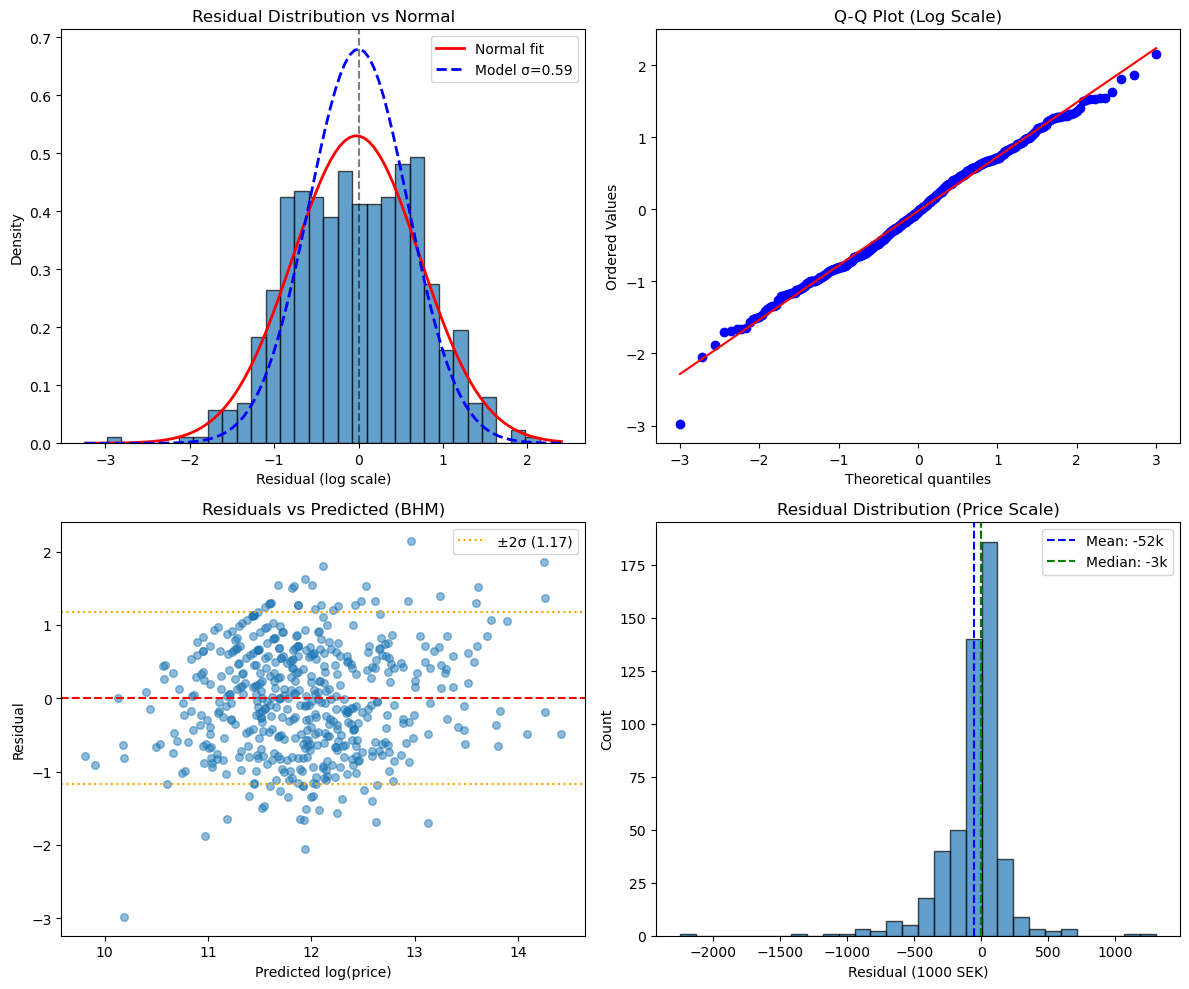


✓ Saved: BHM_residual_analysis.png


In [217]:
# =========================================================
# RESIDUAL ANALYSIS AND NORMALITY TESTS (BHM)
# =========================================================
from scipy import stats

print("="*70)
print("RESIDUAL ANALYSIS (BHM)")
print("="*70)

# Calculate residuals (use BHM variable names)
# y_test is already numpy array, no .values needed
residuals_log = pred_test_log  - y_test 
residuals_price = pred_test_price_bhm - y_test_price 




# ---------------------------------------------------------
# Descriptive statistics
# ---------------------------------------------------------
print(f"\n[RESIDUAL STATISTICS - LOG SCALE]")
print(f"  Mean:     {np.mean(residuals_log):.4f}")
print(f"  Median:   {np.median(residuals_log):.4f}")
print(f"  Std:      {np.std(residuals_log):.4f}")
print(f"  Skewness: {stats.skew(residuals_log):.4f}")
print(f"  Kurtosis: {stats.kurtosis(residuals_log):.4f}")

print(f"\n[RESIDUAL STATISTICS - PRICE SCALE]")
print(f"  Mean:     {np.mean(residuals_price):+,.0f} SEK")
print(f"  Median:   {np.median(residuals_price):+,.0f} SEK")
print(f"  Std:      {np.std(residuals_price):,.0f} SEK")
print(f"  Skewness: {stats.skew(residuals_price):.4f}")
print(f"  Kurtosis: {stats.kurtosis(residuals_price):.4f}")

# ---------------------------------------------------------
# Compare with model's posterior sigma
# ---------------------------------------------------------
print(f"\n[MODEL VS EMPIRICAL RESIDUAL SD]")
posterior_sigma = float(idata_final.posterior['sigma'].mean().values)
empirical_sigma = np.std(residuals_log)
print(f"  Posterior σ (model):    {posterior_sigma:.4f}")
print(f"  Empirical σ (test):     {empirical_sigma:.4f}")
print(f"  Ratio:                  {empirical_sigma/posterior_sigma:.2f}")

if empirical_sigma > posterior_sigma * 1.2:
    print(f"  → Model is overconfident (test residuals larger than expected)")
elif empirical_sigma < posterior_sigma * 0.8:
    print(f"  → Model is underconfident (test residuals smaller than expected)")
else:
    print(f"  → Model uncertainty is well-calibrated ✓")

# ---------------------------------------------------------
# Normality tests (on log scale residuals)
# ---------------------------------------------------------
print(f"\n[NORMALITY TESTS - LOG SCALE]")
print(f"  H0: Residuals are normally distributed")
print(f"  Reject H0 if p < 0.05\n")

# Shapiro-Wilk
if len(residuals_log) <= 5000:
    stat_sw, p_sw = stats.shapiro(residuals_log)
    result_sw = "Normal ✓" if p_sw > 0.05 else "Not Normal ✗"
    print(f"  Shapiro-Wilk:      W = {stat_sw:.4f}, p = {p_sw:.4f}  → {result_sw}")

# D'Agostino-Pearson
#if len(residuals_log) >= 20:
#    stat_dp, p_dp = stats.normaltest(residuals_log)
#    result_dp = "Normal ✓" if p_dp > 0.05 else "Not Normal ✗"
#    print(f"  D'Agostino-Pearson: K² = {stat_dp:.4f}, p = {p_dp:.4f}  → {result_dp}")

# Jarque-Bera
stat_jb, p_jb = stats.jarque_bera(residuals_log)
result_jb = "Normal ✓" if p_jb > 0.05 else "Not Normal ✗"
print(f"  Jarque-Bera:       JB = {stat_jb:.4f}, p = {p_jb:.4f}  → {result_jb}")

# Anderson-Darling
#result_ad = stats.anderson(residuals_log, dist='norm')
#ad_critical_5pct = result_ad.critical_values[2]
#result_ad_txt = "Normal ✓" if result_ad.statistic < ad_critical_5pct else "Not Normal ✗"
#print(f"  Anderson-Darling:  A² = {result_ad.statistic:.4f}, crit(5%) = {ad_critical_5pct:.4f}  → {result_ad_txt}")

# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------
print(f"\n[INTERPRETATION]")
skewness = stats.skew(residuals_log)
kurtosis = stats.kurtosis(residuals_log)

if abs(skewness) < 0.5:
    print(f"  Skewness ({skewness:.2f}): Approximately symmetric ✓")
elif skewness > 0:
    print(f"  Skewness ({skewness:.2f}): Right-skewed (underpredicts expensive horses)")
else:
    print(f"  Skewness ({skewness:.2f}): Left-skewed (overpredicts expensive horses)")

if abs(kurtosis) < 1:
    print(f"  Kurtosis ({kurtosis:.2f}): Near normal tails ✓")
elif kurtosis > 0:
    print(f"  Kurtosis ({kurtosis:.2f}): Heavy tails (more outliers than normal)")
else:
    print(f"  Kurtosis ({kurtosis:.2f}): Light tails (fewer outliers than normal)")

# BHM-specific interpretation
print(f"\n[BHM MODEL ASSUMPTION CHECK]")
print(f"  The BHM assumes: y ~ Normal(μ, σ)")
print(f"  If residuals are approximately normal, assumption is met.")
if abs(skewness) < 0.5 and abs(kurtosis) < 1:
    print(f"  → Normality assumption appears reasonable ✓")
else:
    print(f"  → Some deviation from normality detected")
    print(f"  → Consider: Student-t likelihood for heavy tails")

# ---------------------------------------------------------
# Bias Analysis
# ---------------------------------------------------------
print(f"\n[BIAS ANALYSIS]")
print(f"  Mean Error:   {np.mean(residuals_price):+,.0f} SEK")
print(f"  Median Error: {np.median(residuals_price):+,.0f} SEK")
print(f"  Gap:          {np.mean(residuals_price) - np.median(residuals_price):+,.0f} SEK")

if abs(np.mean(residuals_price)) > 2 * abs(np.median(residuals_price)):
    print(f"\n  → Mean >> Median: Outliers driving the bias")
    print(f"  → Using no correction (median prediction) is appropriate")
else:
    print(f"\n  → Systematic bias detected")

# ---------------------------------------------------------
# Visual diagnostics
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) Histogram with normal overlay
ax1 = axes[0, 0]
ax1.hist(residuals_log, bins=30, density=True, alpha=0.7, edgecolor='black')
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
ax1.plot(x, stats.norm.pdf(x, np.mean(residuals_log), np.std(residuals_log)), 
         'r-', linewidth=2, label='Normal fit')
# Also plot the model's posterior sigma
ax1.plot(x, stats.norm.pdf(x, 0, posterior_sigma), 
         'b--', linewidth=2, label=f'Model σ={posterior_sigma:.2f}')
ax1.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Residual (log scale)')
ax1.set_ylabel('Density')
ax1.set_title('Residual Distribution vs Normal')
ax1.legend()

# 2) Q-Q plot
ax2 = axes[0, 1]
stats.probplot(residuals_log, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Log Scale)')

# 3) Residuals vs Predicted
ax3 = axes[1, 0]
ax3.scatter(pred_test_log, residuals_log, alpha=0.5, s=30)
ax3.axhline(y=0, color='r', linestyle='--')
# Add +/- 2 sigma bands
ax3.axhline(y=2*posterior_sigma, color='orange', linestyle=':', label=f'±2σ ({2*posterior_sigma:.2f})')
ax3.axhline(y=-2*posterior_sigma, color='orange', linestyle=':')
ax3.set_xlabel('Predicted log(price)')
ax3.set_ylabel('Residual')
ax3.set_title('Residuals vs Predicted (BHM)')
ax3.legend()

# 4) Price scale residuals
ax4 = axes[1, 1]
ax4.hist(residuals_price/1000, bins=30, alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='black', linestyle='--')
ax4.axvline(x=np.mean(residuals_price)/1000, color='blue', linestyle='--', 
            label=f'Mean: {np.mean(residuals_price)/1000:+.0f}k')
ax4.axvline(x=np.median(residuals_price)/1000, color='green', linestyle='--', 
            label=f'Median: {np.median(residuals_price)/1000:+.0f}k')
ax4.set_xlabel('Residual (1000 SEK)')
ax4.set_ylabel('Count')
ax4.set_title('Residual Distribution (Price Scale)')
ax4.legend()

plt.tight_layout()
plt.savefig('BHM_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: BHM_residual_analysis.png")

In [162]:
# =========================================================
# COMPLETE VARIANCE DECOMPOSITION
# =========================================================

print("="*70)
print("COMPLETE VARIANCE DECOMPOSITION")
print("="*70)

# Extract sigma values from posterior
sigma_sire_est = float(idata_final.posterior['sigma_sire'].mean().values)
sigma_dam_sire_est = float(idata_final.posterior['sigma_dam_sire'].mean().values)
sigma_breeder_est = float(idata_final.posterior['sigma_breeder'].mean().values)
sigma_residual_est = float(idata_final.posterior['sigma'].mean().values)

# Total variance in outcome
total_var_y = np.var(y_train)
print(f"\n[TOTAL VARIANCE IN LOG-PRICE]")
print(f"  Var(y_train) = {total_var_y:.4f}")

# Variance explained by fixed effects
fixed_effects_pred = (
    float(idata_final.posterior['intercept'].mean().values) +
    X_train_scaled @ idata_final.posterior['beta'].mean(dim=['chain', 'draw']).values 
  #  float(idata_final.posterior['year_coef'].mean().values) * year_centered_train +
  #  float(idata_final.posterior['auction_coef'].mean().values) * auction_binary_train
)
var_fixed = np.var(fixed_effects_pred)

# Variance from random effects
var_sire = sigma_sire_est**2
var_dam_sire = sigma_dam_sire_est**2
var_breeder = sigma_breeder_est**2
var_residual = sigma_residual_est**2

# Total explained by random effects
var_random_total = var_sire + var_dam_sire + var_breeder

print(f"\n[VARIANCE COMPONENTS - ABSOLUTE]")
print(f"  Fixed effects (Xβ + year + auction): {var_fixed:.4f}")
print(f"  Sire random effect:                  {var_sire:.4f}")
print(f"  Dam Sire random effect:              {var_dam_sire:.4f}")
print(f"  Breeder random effect:               {var_breeder:.4f}")
print(f"  Residual:                            {var_residual:.4f}")

print(f"\n[VARIANCE COMPONENTS - % OF TOTAL]")
print(f"  Fixed effects (Xβ + year + auction): {100*var_fixed/total_var_y:.1f}%")
print(f"  Sire random effect:                  {100*var_sire/total_var_y:.1f}%")
print(f"  Dam Sire random effect:              {100*var_dam_sire/total_var_y:.1f}%")
print(f"  Breeder random effect:               {100*var_breeder/total_var_y:.1f}%")
print(f"  Residual:                            {100*var_residual/total_var_y:.1f}%")

print(f"\n[SUMMARY]")
print(f"  Model explained (fixed + random): {100*(var_fixed + var_random_total)/total_var_y:.1f}%")
print(f"  Residual:                         {100*var_residual/total_var_y:.1f}%")

print(f"\n[WITHIN RANDOM EFFECTS ONLY]")
var_random_plus_resid = var_sire + var_dam_sire + var_breeder + var_residual
print(f"  Sire:      {100*var_sire/var_random_plus_resid:.1f}%")
print(f"  Dam Sire:  {100*var_dam_sire/var_random_plus_resid:.1f}%")
print(f"  Breeder:   {100*var_breeder/var_random_plus_resid:.1f}%")
print(f"  Residual:  {100*var_residual/var_random_plus_resid:.1f}%")

print(f"\n[COMPARISON WITH R²]")
print(f"  Train R² (actual):  {r2_score(y_train, pred_train_log):.4f}")

COMPLETE VARIANCE DECOMPOSITION

[TOTAL VARIANCE IN LOG-PRICE]
  Var(y_train) = 1.0164

[VARIANCE COMPONENTS - ABSOLUTE]
  Fixed effects (Xβ + year + auction): 0.5238
  Sire random effect:                  0.0637
  Dam Sire random effect:              0.0067
  Breeder random effect:               0.0514
  Residual:                            0.3445

[VARIANCE COMPONENTS - % OF TOTAL]
  Fixed effects (Xβ + year + auction): 51.5%
  Sire random effect:                  6.3%
  Dam Sire random effect:              0.7%
  Breeder random effect:               5.1%
  Residual:                            33.9%

[SUMMARY]
  Model explained (fixed + random): 63.5%
  Residual:                         33.9%

[WITHIN RANDOM EFFECTS ONLY]
  Sire:      13.7%
  Dam Sire:  1.4%
  Breeder:   11.0%
  Residual:  73.9%

[COMPARISON WITH R²]
  Train R² (actual):  0.7099


In [182]:
# =========================================================
# FEATURE IMPORTANCE TABLES - EXPORT TO WORD
# =========================================================

from docx import Document
import numpy as np

doc = Document()

# ---------------------------------------------------------
# 1. Extract values from posterior
# ---------------------------------------------------------
sigma_sire = float(idata_final.posterior['sigma_sire'].mean().values)
sigma_dam_sire = float(idata_final.posterior['sigma_dam_sire'].mean().values)
sigma_breeder = float(idata_final.posterior['sigma_breeder'].mean().values)
sigma_residual = float(idata_final.posterior['sigma'].mean().values)

# Variance components
var_sire = sigma_sire**2
var_dam_sire = sigma_dam_sire**2
var_breeder = sigma_breeder**2
var_residual = sigma_residual**2
var_random_total = var_sire + var_dam_sire + var_breeder

# Total variance
total_var_train = np.var(y_train)
total_var_test = np.var(y_test)

# Fixed effects variance
fixed_pred_train = (
    float(idata_final.posterior['intercept'].mean().values) +
    X_train_scaled @ idata_final.posterior['beta'].mean(dim=['chain', 'draw']).values 
   # float(idata_final.posterior['year_coef'].mean().values) * year_centered_train +
   # float(idata_final.posterior['auction_coef'].mean().values) * auction_binary_train
)
var_fixed_train = np.var(fixed_pred_train)

fixed_pred_test = (
    float(idata_final.posterior['intercept'].mean().values) +
    X_test_scaled @ idata_final.posterior['beta'].mean(dim=['chain', 'draw']).values 
  #  float(idata_final.posterior['year_coef'].mean().values) * year_centered_test +
  #  float(idata_final.posterior['auction_coef'].mean().values) * auction_binary_test
)
var_fixed_test = np.var(fixed_pred_test)

# Empirical residual variance
empirical_resid_train = np.var(y_train - pred_train_log)
empirical_resid_test = np.var(y_test - pred_test_log)

# ---------------------------------------------------------
# Table 1: Variance Decomposition
# ---------------------------------------------------------
doc.add_heading('Table X: Variance Decomposition', level=2)

table1 = doc.add_table(rows=4, cols=3)
table1.style = 'Table Grid'

headers1 = ['Component', 'Train', 'Test']
for i, h in enumerate(headers1):
    table1.rows[0].cells[i].text = h

data1 = [
    ['Fixed effects', f'{100*var_fixed_train/total_var_train:.1f}%', f'{100*var_fixed_test/total_var_test:.1f}%'],
    ['Random effects', f'{100*var_random_total/total_var_train:.1f}%', f'{100*var_random_total/total_var_test:.1f}%'],
    ['Residual (empirical)', f'{100*empirical_resid_train/total_var_train:.1f}%', f'{100*empirical_resid_test/total_var_test:.1f}%']
]

for row_idx, row_data in enumerate(data1, start=1):
    for col_idx, value in enumerate(row_data):
        table1.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph()

# ---------------------------------------------------------
# Table 2: Random Effects Decomposition
# ---------------------------------------------------------
doc.add_heading('Table X: Random Effects Decomposition', level=2)

table2 = doc.add_table(rows=5, cols=4)
table2.style = 'Table Grid'

headers2 = ['Random Effect', 'σ', 'Variance (σ²)', '% of Total']
for i, h in enumerate(headers2):
    table2.rows[0].cells[i].text = h

data2 = [
    ['Sire', f'{sigma_sire:.3f}', f'{var_sire:.4f}', f'{100*var_sire/total_var_train:.1f}%'],
    ['Breeder', f'{sigma_breeder:.3f}', f'{var_breeder:.4f}', f'{100*var_breeder/total_var_train:.1f}%'],
    ['Dam Sire', f'{sigma_dam_sire:.3f}', f'{var_dam_sire:.4f}', f'{100*var_dam_sire/total_var_train:.1f}%'],
    ['Total Random', '—', f'{var_random_total:.4f}', f'{100*var_random_total/total_var_train:.1f}%']
]

for row_idx, row_data in enumerate(data2, start=1):
    for col_idx, value in enumerate(row_data):
        table2.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph()


# ---------------------------------------------------------
# Table 3: Fixed Effects (ALL COEFFICIENTS)
# ---------------------------------------------------------
doc.add_heading('Table X: Feature Coefficients', level=2)

# Extract beta coefficients
beta_samples = idata_final.posterior['beta']
beta_mean = beta_samples.mean(dim=['chain', 'draw']).values
beta_hdi = az.hdi(idata_final, var_names=['beta'], hdi_prob=0.94)['beta'].values

# Create DataFrame and sort by absolute value
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': beta_mean,
    'HDI_low': beta_hdi[:, 0],
    'HDI_high': beta_hdi[:, 1]
})
coef_df['Significant'] = (coef_df['HDI_low'] > 0) | (coef_df['HDI_high'] < 0)
coef_df['Abs_Coef'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)  # All features

# Dynamic row count: 1 header + number of features
n_rows = len(coef_df) + 1

table3 = doc.add_table(rows=n_rows, cols=4)
table3.style = 'Table Grid'

headers3 = ['Feature', 'Coefficient', '94% HDI', 'Sig']
for i, h in enumerate(headers3):
    table3.rows[0].cells[i].text = h

for row_idx, (_, row) in enumerate(coef_df.iterrows(), start=1):
    table3.rows[row_idx].cells[0].text = row['Feature']
    table3.rows[row_idx].cells[1].text = f"{row['Coefficient']:+.3f}"
    table3.rows[row_idx].cells[2].text = f"[{row['HDI_low']:+.3f}, {row['HDI_high']:+.3f}]"
    table3.rows[row_idx].cells[3].text = "***" if row['Significant'] else ""

# ---------------------------------------------------------
# Print summary
# ---------------------------------------------------------
print("="*70)
print("FEATURE IMPORTANCE SUMMARY")
print("="*70)

print(f"\n[VARIANCE DECOMPOSITION]")
print(f"  Fixed effects:  {100*var_fixed_train/total_var_train:.1f}% (train), {100*var_fixed_test/total_var_test:.1f}% (test)")
print(f"  Random effects: {100*var_random_total/total_var_train:.1f}% (train), {100*var_random_total/total_var_test:.1f}% (test)")
print(f"  Residual:       {100*empirical_resid_train/total_var_train:.1f}% (train), {100*empirical_resid_test/total_var_test:.1f}% (test)")

print(f"\n[RANDOM EFFECTS BREAKDOWN]")
print(f"  Sire:     σ={sigma_sire:.3f}, {100*var_sire/total_var_train:.1f}% of variance")
print(f"  Breeder:  σ={sigma_breeder:.3f}, {100*var_breeder/total_var_train:.1f}% of variance")
print(f"  Dam Sire: σ={sigma_dam_sire:.3f}, {100*var_dam_sire/total_var_train:.1f}% of variance")

print(f"\n[TOP 5 COEFFICIENTS]")
for _, row in coef_df.head(5).iterrows():
    sig = "***" if row['Significant'] else ""
    print(f"  {row['Feature']:<25} {row['Coefficient']:+.3f} {sig}")

# Save
doc.save('BHM_feature_importance_tables.docx')
print(f"\n✓ Saved: BHM_feature_importance_tables.docx")

FEATURE IMPORTANCE SUMMARY

[VARIANCE DECOMPOSITION]
  Fixed effects:  51.5% (train), 44.6% (test)
  Random effects: 12.0% (train), 12.3% (test)
  Residual:       29.0% (train), 57.0% (test)

[RANDOM EFFECTS BREAKDOWN]
  Sire:     σ=0.252, 6.3% of variance
  Breeder:  σ=0.227, 5.1% of variance
  Dam Sire: σ=0.082, 0.7% of variance

[TOP 5 COEFFICIENTS]
  Log_stud_fee              +0.443 ***
  Gender                    +0.220 ***
  Selective_Auctions        +0.180 ***
  SiblingEarningsPerHorse   +0.136 ***
  Dam_Never_Raced           +0.117 ***

✓ Saved: BHM_feature_importance_tables.docx


In [227]:
from docx import Document

doc = Document()

# ---------------------------------------------------------
# Table 1: Residual Diagnostics
# ---------------------------------------------------------
doc.add_heading('Table 4.X: BHM Residual Diagnostics (Test Set, n=510)', level=2)

table1 = doc.add_table(rows=5, cols=3)
table1.style = 'Table Grid'

headers1 = ['Metric', 'Log Scale', 'Price Scale']
for i, header in enumerate(headers1):
    table1.rows[0].cells[i].text = header

data1 = [
    ['Mean', '0.004', '−7,454 SEK'],
    ['Std. Dev.', '0.76', '266,024 SEK'],
    ['Skewness', '0.04', '0.02'],
    ['Kurtosis', '−0.16', '17.47']
]

for row_idx, row_data in enumerate(data1, start=1):
    for col_idx, value in enumerate(row_data):
        table1.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph()  # Space between tables

# ---------------------------------------------------------
# Table 2: Normality Tests
# ---------------------------------------------------------
doc.add_heading('Table 4.X: Normality Tests (Log Scale Residuals)', level=2)

table2 = doc.add_table(rows=3, cols=4)
table2.style = 'Table Grid'

headers2 = ['Test', 'Statistic', 'p-value', 'Result']
for i, header in enumerate(headers2):
    table2.rows[0].cells[i].text = header

data2 = [
    ['Shapiro-Wilk', 'W = 0.995', '0.063', 'Normal ✓'],
    ['Jarque-Bera', 'JB = 0.69', '0.708', 'Normal ✓']
]

for row_idx, row_data in enumerate(data2, start=1):
    for col_idx, value in enumerate(row_data):
        table2.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph()

# ---------------------------------------------------------
# Table 3: Model Calibration
# ---------------------------------------------------------
doc.add_heading('Table 4.X: Uncertainty Calibration', level=2)

table3 = doc.add_table(rows=4, cols=2)
table3.style = 'Table Grid'

headers3 = ['Metric', 'Value']
for i, header in enumerate(headers3):
    table3.rows[0].cells[i].text = header

data3 = [
    ['Posterior σ (model)', '0.59'],
    ['Empirical σ (test)', '0.76'],
    ['Ratio', '1.29 (overconfident)']
]

for row_idx, row_data in enumerate(data3, start=1):
    for col_idx, value in enumerate(row_data):
        table3.rows[row_idx].cells[col_idx].text = value

# Save
doc.save('BHM_diagnostic_tables.docx')
print("✓ Saved: BHM_diagnostic_tables.docx")

✓ Saved: BHM_diagnostic_tables.docx


In [213]:
# =========================================================
# VARIANCE DECOMPOSITION - TRAIN VS TEST
# =========================================================

print("="*70)
print("VARIANCE DECOMPOSITION - TRAIN VS TEST COMPARISON")
print("="*70)

# --- TRAINING DATA ---
total_var_train = np.var(y_train)

fixed_pred_train = (
    float(idata_final.posterior['intercept'].mean().values) +
    X_train_scaled @ idata_final.posterior['beta'].mean(dim=['chain', 'draw']).values 
   # float(idata_final.posterior['year_coef'].mean().values) * year_centered_train +
   # float(idata_final.posterior['auction_coef'].mean().values) * auction_binary_train
)
var_fixed_train = np.var(fixed_pred_train)

# --- TEST DATA ---
total_var_test = np.var(y_test)

fixed_pred_test = (
    float(idata_final.posterior['intercept'].mean().values) +
    X_test_scaled @ idata_final.posterior['beta'].mean(dim=['chain', 'draw']).values 
  #  float(idata_final.posterior['year_coef'].mean().values) * year_centered_test +
  #  float(idata_final.posterior['auction_coef'].mean().values) * auction_binary_test
)
var_fixed_test = np.var(fixed_pred_test)

# Sigma estimates (same for both, from posterior)
var_sire = sigma_sire_est**2
var_dam_sire = sigma_dam_sire_est**2
var_breeder = sigma_breeder_est**2
var_residual = sigma_residual_est**2
var_random = var_sire + var_dam_sire + var_breeder

# Actual residual variance (empirical)
empirical_resid_train = np.var(y_train - pred_train_log)
empirical_resid_test = np.var(y_test - pred_test_log)

print(f"\n{'Component':<35} {'Train':>12} {'Test':>12}")
print("-" * 60)
print(f"{'Total variance in log-price':<35} {total_var_train:>12.4f} {total_var_test:>12.4f}")
print(f"{'Fixed effects variance':<35} {var_fixed_train:>12.4f} {var_fixed_test:>12.4f}")
print(f"{'Random effects variance (model)':<35} {var_random:>12.4f} {var_random:>12.4f}")
print(f"{'Residual variance (model σ²)':<35} {var_residual:>12.4f} {var_residual:>12.4f}")
print(f"{'Residual variance (empirical)':<35} {empirical_resid_train:>12.4f} {empirical_resid_test:>12.4f}")

print(f"\n{'% OF TOTAL VARIANCE':<35} {'Train':>12} {'Test':>12}")
print("-" * 60)
print(f"{'Fixed effects':<35} {100*var_fixed_train/total_var_train:>11.1f}% {100*var_fixed_test/total_var_test:>11.1f}%")
print(f"{'Random effects (model)':<35} {100*var_random/total_var_train:>11.1f}% {100*var_random/total_var_test:>11.1f}%")
print(f"{'Residual (model σ²)':<35} {100*var_residual/total_var_train:>11.1f}% {100*var_residual/total_var_test:>11.1f}%")
print(f"{'Residual (empirical)':<35} {100*empirical_resid_train/total_var_train:>11.1f}% {100*empirical_resid_test/total_var_test:>11.1f}%")

print(f"\n{'ACTUAL R²':<35} {'Train':>12} {'Test':>12}")
print("-" * 60)
print(f"{'R² (log scale)':<35} {r2_score(y_train, pred_train_log):>12.4f} {r2_score(y_test, pred_test_log):>12.4f}")

VARIANCE DECOMPOSITION - TRAIN VS TEST COMPARISON

Component                                  Train         Test
------------------------------------------------------------
Total variance in log-price               1.0164       0.9938
Fixed effects variance                    0.5238       0.4434
Random effects variance (model)           0.1218       0.1218
Residual variance (model σ²)              0.3445       0.3445
Residual variance (empirical)             0.2948       0.5664

% OF TOTAL VARIANCE                        Train         Test
------------------------------------------------------------
Fixed effects                              51.5%        44.6%
Random effects (model)                     12.0%        12.3%
Residual (model σ²)                        33.9%        34.7%
Residual (empirical)                       29.0%        57.0%

ACTUAL R²                                  Train         Test
------------------------------------------------------------
R² (log scale)      

CALIBRATION ANALYSIS (BHM)

[CALIBRATION BY PREDICTION DECILE]
Decile           Pred       Actual       Diff   Diff %   Pred Log    Act Log   Diff Log     N
-----------------------------------------------------------------------------------------------
D1             47,585       78,333    +30,749   +64.6%     10.732     10.993     +0.261    51
D2             74,122       86,471    +12,349   +16.7%     11.210     11.157     -0.052    51
D3             95,192      116,667    +21,474   +22.6%     11.463     11.408     -0.054    51
D4            112,458      129,706    +17,248   +15.3%     11.629     11.486     -0.143    51
D5            134,786      168,725    +33,939   +25.2%     11.810     11.737     -0.073    51
D6            158,670      287,647   +128,977   +81.3%     11.974     12.282     +0.308    51
D7            187,979      250,784    +62,805   +33.4%     12.143     12.169     +0.027    51
D8            233,595      353,529   +119,935   +51.3%     12.359     12.584     +0.225  

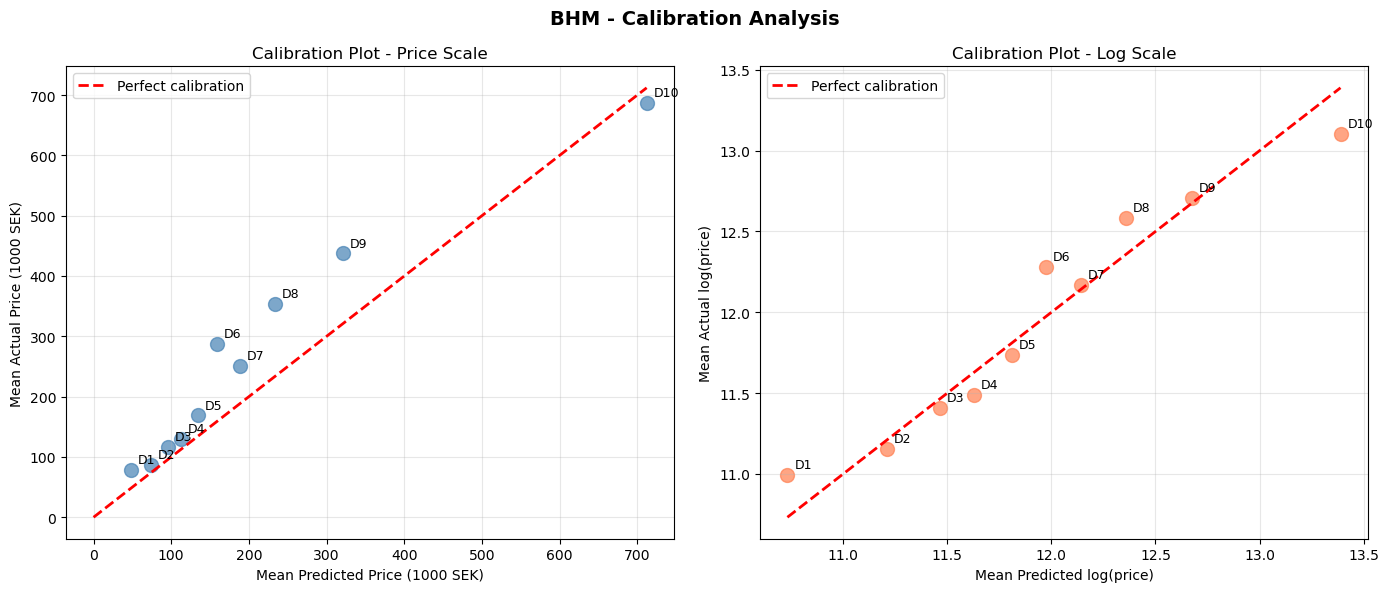

✓ Saved: BHM_calibration_plot.png

[CALIBRATION ERROR METRICS]
  Expected Calibration Error (ECE): 56,945 SEK
  Maximum Calibration Error (MCE):  128,977 SEK (Decile 6)
  RMS Calibration Error (RMSCE):    72,223 SEK

[INTERPRETATION]
  The calibration plot shows how well predictions match actual prices
  across the prediction range. Points above the diagonal indicate
  underprediction; points below indicate overprediction.

  For BHM, expect higher deciles (D8-D10) to fall above the line
  due to Bayesian shrinkage pulling extreme predictions toward the mean.


In [77]:
# =========================================================
# CALIBRATION ANALYSIS (BHM)
# =========================================================

print("="*70)
print("CALIBRATION ANALYSIS (BHM)")
print("="*70)

# Number of bins (deciles)
n_bins = 10

# Create bins based on predicted prices
pred_quantiles = pd.qcut(pred_test_price_bhm, q=n_bins, labels=False, duplicates='drop')

# Calculate mean predicted and actual for each bin
calibration_df = pd.DataFrame({
    'predicted': pred_test_price_bhm,
    'actual': y_test_price,
    'predicted_log': pred_test_log,
    'actual_log': y_test,
    'bin': pred_quantiles
})


calibration_summary = calibration_df.groupby('bin').agg(
    mean_predicted=('predicted', 'mean'),
    mean_actual=('actual', 'mean'),
    mean_predicted_log=('predicted_log', 'mean'),
    mean_actual_log=('actual_log', 'mean'),
    count=('actual', 'count')
).reset_index()

# Calculate differences
calibration_summary['diff_price'] = calibration_summary['mean_actual'] - calibration_summary['mean_predicted']
calibration_summary['diff_pct'] = (calibration_summary['diff_price'] / calibration_summary['mean_predicted']) * 100
calibration_summary['diff_log'] = calibration_summary['mean_actual_log'] - calibration_summary['mean_predicted_log']

print(f"\n[CALIBRATION BY PREDICTION DECILE]")
print(f"{'Decile':<8} {'Pred':>12} {'Actual':>12} {'Diff':>10} {'Diff %':>8} {'Pred Log':>10} {'Act Log':>10} {'Diff Log':>10} {'N':>5}")
print("-" * 95)

for _, row in calibration_summary.iterrows():
    print(f"D{int(row['bin'])+1:<7} {row['mean_predicted']:>12,.0f} {row['mean_actual']:>12,.0f} "
          f"{row['diff_price']:>+10,.0f} {row['diff_pct']:>+7.1f}% "
          f"{row['mean_predicted_log']:>10.3f} {row['mean_actual_log']:>10.3f} {row['diff_log']:>+10.3f} "
          f"{int(row['count']):>5}")

# ---------------------------------------------------------
# Summary statistics
# ---------------------------------------------------------
mean_diff = calibration_summary['diff_price'].mean()
low_decile_bias = calibration_summary[calibration_summary['bin'] <= 2]['diff_price'].mean()
high_decile_bias = calibration_summary[calibration_summary['bin'] >= 7]['diff_price'].mean()

print(f"\n[CALIBRATION SUMMARY]")
print(f"  Mean difference across deciles: {mean_diff:+,.0f} SEK")
print(f"  Low deciles (D1-D3) avg bias:   {low_decile_bias:+,.0f} SEK")
print(f"  High deciles (D8-D10) avg bias: {high_decile_bias:+,.0f} SEK")

if high_decile_bias > 0:
    print(f"  → Model underpredicts expensive horses (shrinkage effect)")
elif high_decile_bias < 0:
    print(f"  → Model overpredicts expensive horses")

# ---------------------------------------------------------
# Calibration Plot
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Price scale
ax1 = axes[0]
ax1.scatter(calibration_summary['mean_predicted']/1000, 
            calibration_summary['mean_actual']/1000, 
            s=100, alpha=0.7, c='steelblue')

# Add decile labels
for _, row in calibration_summary.iterrows():
    ax1.annotate(f"D{int(row['bin'])+1}", 
                 (row['mean_predicted']/1000, row['mean_actual']/1000),
                 textcoords="offset points", xytext=(5,5), fontsize=9)

# Perfect calibration line
max_val = max(calibration_summary['mean_predicted'].max(), 
              calibration_summary['mean_actual'].max()) / 1000
ax1.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect calibration')
ax1.set_xlabel('Mean Predicted Price (1000 SEK)')
ax1.set_ylabel('Mean Actual Price (1000 SEK)')
ax1.set_title('Calibration Plot - Price Scale')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log scale
ax2 = axes[1]
ax2.scatter(calibration_summary['mean_predicted_log'], 
            calibration_summary['mean_actual_log'], 
            s=100, alpha=0.7, c='coral')

for _, row in calibration_summary.iterrows():
    ax2.annotate(f"D{int(row['bin'])+1}", 
                 (row['mean_predicted_log'], row['mean_actual_log']),
                 textcoords="offset points", xytext=(5,5), fontsize=9)

max_log = max(calibration_summary['mean_predicted_log'].max(), 
              calibration_summary['mean_actual_log'].max())
min_log = min(calibration_summary['mean_predicted_log'].min(), 
              calibration_summary['mean_actual_log'].min())
ax2.plot([min_log, max_log], [min_log, max_log], 'r--', lw=2, label='Perfect calibration')
ax2.set_xlabel('Mean Predicted log(price)')
ax2.set_ylabel('Mean Actual log(price)')
ax2.set_title('Calibration Plot - Log Scale')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('BHM - Calibration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('BHM_calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: BHM_calibration_plot.png")

# ---------------------------------------------------------
# Calibration Error Metrics
# ---------------------------------------------------------
ece = calibration_summary['diff_price'].abs().mean()
mce = calibration_summary['diff_price'].abs().max()
rmsce = np.sqrt((calibration_summary['diff_price']**2).mean())

print(f"\n[CALIBRATION ERROR METRICS]")
print(f"  Expected Calibration Error (ECE): {ece:,.0f} SEK")
print(f"  Maximum Calibration Error (MCE):  {mce:,.0f} SEK (Decile {calibration_summary['diff_price'].abs().idxmax() + 1})")
print(f"  RMS Calibration Error (RMSCE):    {rmsce:,.0f} SEK")

# ---------------------------------------------------------
# Compare with XGBoost (if available)
# ---------------------------------------------------------
print(f"\n[INTERPRETATION]")
print(f"  The calibration plot shows how well predictions match actual prices")
print(f"  across the prediction range. Points above the diagonal indicate")
print(f"  underprediction; points below indicate overprediction.")
print(f"\n  For BHM, expect higher deciles (D8-D10) to fall above the line")
print(f"  due to Bayesian shrinkage pulling extreme predictions toward the mean.")

In [79]:
# =========================================================
# CALIBRATION TABLE - EXPORT TO WORD (DYNAMIC)
# =========================================================

from docx import Document

doc = Document()

# ---------------------------------------------------------
# Table 1: Calibration by Decile (from calibration_summary DataFrame)
# ---------------------------------------------------------
doc.add_heading('Table X: Calibration by Prediction Decile', level=2)

table1 = doc.add_table(rows=len(calibration_summary) + 1, cols=5)
table1.style = 'Table Grid'

headers1 = ['Decile', 'Mean Predicted (SEK)', 'Mean Actual (SEK)', 'Difference (SEK)', 'Difference (%)']
for i, h in enumerate(headers1):
    table1.rows[0].cells[i].text = h

for row_idx, row in calibration_summary.iterrows():
    table1.rows[row_idx + 1].cells[0].text = f"D{int(row['bin']) + 1}"
    table1.rows[row_idx + 1].cells[1].text = f"{row['mean_predicted']:,.0f}"
    table1.rows[row_idx + 1].cells[2].text = f"{row['mean_actual']:,.0f}"
    table1.rows[row_idx + 1].cells[3].text = f"{row['diff_price']:+,.0f}"
    table1.rows[row_idx + 1].cells[4].text = f"{row['diff_pct']:+.1f}%"

doc.add_paragraph()

# ---------------------------------------------------------
# Table 2: Calibration Summary by Group (calculated dynamically)
# ---------------------------------------------------------
doc.add_heading('Table X: Calibration Summary by Decile Group', level=2)

# Calculate group averages
low_bias = calibration_summary[calibration_summary['bin'] <= 2]['diff_price'].mean()
mid_bias = calibration_summary[(calibration_summary['bin'] >= 3) & (calibration_summary['bin'] <= 6)]['diff_price'].mean()
high_bias = calibration_summary[calibration_summary['bin'] >= 7]['diff_price'].mean()

# Determine pattern labels
def get_pattern(bias):
    if abs(bias) < 10000:
        return "Well calibrated"
    elif bias > 0:
        return "Underprediction"
    else:
        return "Overprediction"

table2 = doc.add_table(rows=4, cols=3)
table2.style = 'Table Grid'

headers2 = ['Decile Group', 'Avg Bias (SEK)', 'Pattern']
for i, h in enumerate(headers2):
    table2.rows[0].cells[i].text = h

summary_data = [
    ['D1–D3 (low)', f'{low_bias:+,.0f}', get_pattern(low_bias)],
    ['D4–D7 (mid)', f'{mid_bias:+,.0f}', get_pattern(mid_bias)],
    ['D8–D10 (high)', f'{high_bias:+,.0f}', get_pattern(high_bias)]
]

for row_idx, row_data in enumerate(summary_data, start=1):
    for col_idx, value in enumerate(row_data):
        table2.rows[row_idx].cells[col_idx].text = value

# ---------------------------------------------------------
# Print summary for reference
# ---------------------------------------------------------
print("[CALIBRATION SUMMARY]")
print(f"  Low deciles (D1-D3):  {low_bias:+,.0f} SEK - {get_pattern(low_bias)}")
print(f"  Mid deciles (D4-D7):  {mid_bias:+,.0f} SEK - {get_pattern(mid_bias)}")
print(f"  High deciles (D8-D10): {high_bias:+,.0f} SEK - {get_pattern(high_bias)}")

# Save
doc.save('BHM_calibration_tables.docx')
print("\n✓ Saved: BHM_calibration_tables.docx")

[CALIBRATION SUMMARY]
  Low deciles (D1-D3):  +21,524 SEK - Underprediction
  Mid deciles (D4-D7):  +60,742 SEK - Underprediction
  High deciles (D8-D10): +70,202 SEK - Underprediction

✓ Saved: BHM_calibration_tables.docx


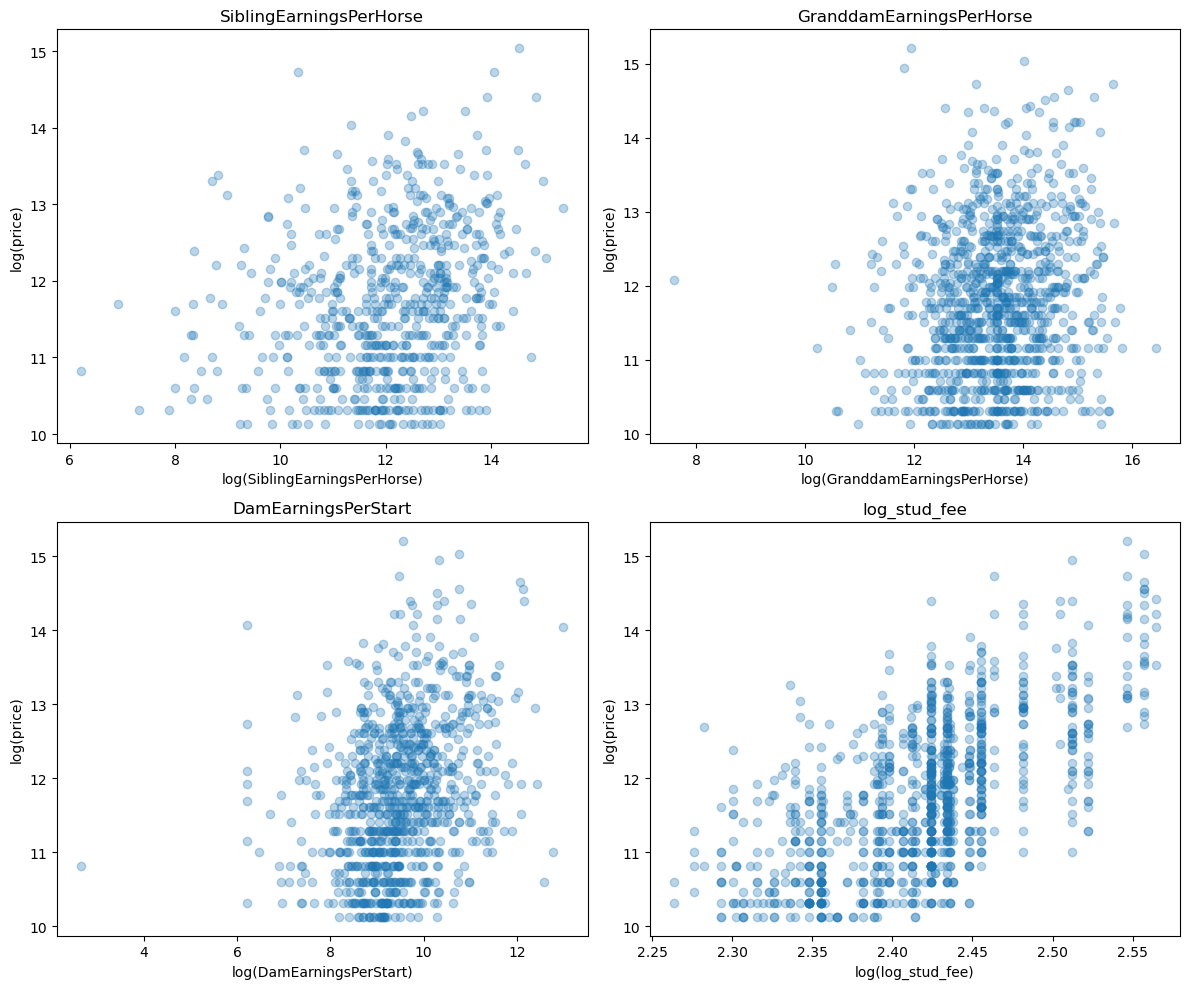

In [81]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flat, ['SiblingEarningsPerHorse', 'GranddamEarningsPerHorse', 
                                'DamEarningsPerStart', 'Log_stud_fee']):
    if col in df_train.columns:
        data = df_train[col].dropna()
        data = data[data > 0]  # for log
        ax.scatter(np.log(data), df_train.loc[data.index, 'log_price'], alpha=0.3)
        ax.set_xlabel(f'log({col})')
        ax.set_ylabel('log(price)')
        ax.set_title(col)
plt.tight_layout()
plt.show()

In [215]:
# =========================================================
# PERFORMANCE METRICS - EXPORT TO WORD
# =========================================================

from docx import Document
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
from scipy.stats import spearmanr, kendalltau
import numpy as np

print("="*70)
print("PERFORMANCE METRICS SUMMARY")
print("="*70)

# ---------------------------------------------------------
# 1. Log-Scale Metrics
# ---------------------------------------------------------
train_r2_log = r2_score(y_train, pred_train_log)
test_r2_log = r2_score(y_test, pred_test_log)
test_rmse_log = np.sqrt(mean_squared_error(y_test, pred_test_log))
test_mae_log = mean_absolute_error(y_test, pred_test_log)

print(f"\n[LOG-SCALE METRICS]")
print(f"  Train R²:  {train_r2_log:.4f}")
print(f"  Test R²:   {test_r2_log:.4f}")
print(f"  Test RMSE: {test_rmse_log:.4f}")
print(f"  Test MAE:  {test_mae_log:.4f}")

# ---------------------------------------------------------
# 2. Price-Scale Metrics
# ---------------------------------------------------------
y_test_price = np.exp(y_test)
y_train_price = np.exp(y_train)

# MdAPE and MAPE
ape_test = np.abs((y_test_price - pred_test_price_bhm) / y_test_price) * 100
mdape = np.median(ape_test)
mape = np.mean(ape_test)

# R² on price scale
test_r2_price = r2_score(y_test_price, pred_test_price_bhm)

print(f"\n[PRICE-SCALE METRICS]")
print(f"  Test R²:   {test_r2_price:.4f}")
print(f"  MdAPE:     {mdape:.1f}%")
print(f"  MAPE:      {mape:.1f}%")

# ---------------------------------------------------------
# 3. Top-Decile / Ranking Metrics
# ---------------------------------------------------------
# Spearman and Kendall
spearman_corr, spearman_p = spearmanr(y_test_price, pred_test_price_bhm)
kendall_corr, kendall_p = kendalltau(y_test_price, pred_test_price_bhm)

# Top-K Hit Rate (K = 10%)
k = int(len(y_test_price) * 0.10)
top_k_pred_idx = np.argsort(pred_test_price_bhm)[::-1][:k]
top_decile_threshold = np.percentile(y_test_price, 90)
actual_top_decile = y_test_price >= top_decile_threshold
hits = actual_top_decile[top_k_pred_idx].sum()
hit_rate = hits / k

# Precision and Recall for top decile
predicted_top_decile = pred_test_price_bhm >= np.percentile(pred_test_price_bhm, 90)
tp = np.sum(actual_top_decile & predicted_top_decile)
fp = np.sum(~actual_top_decile & predicted_top_decile)
fn = np.sum(actual_top_decile & ~predicted_top_decile)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

# NDCG Score
y_true_relevance = (y_test_price / y_test_price.max()).reshape(1, -1)
y_pred_scores = pred_test_price_bhm.reshape(1, -1)
ndcg = ndcg_score(y_true_relevance, y_pred_scores)

print(f"\n[RANKING METRICS]")
print(f"  Spearman ρ:  {spearman_corr:.4f} (p={spearman_p:.2e})")
#print(f"  Kendall τ:   {kendall_corr:.4f} (p={kendall_p:.2e})")
print(f"  NDCG:        {ndcg:.4f}")

print(f"\n[TOP-DECILE IDENTIFICATION]")
print(f"  Hit Rate:    {hit_rate:.1%} ({hits}/{k})")
#print(f"  Precision:   {precision:.3f}")
#print(f"  Recall:      {recall:.3f}")

# ---------------------------------------------------------
# 4. Export to Word
# ---------------------------------------------------------
doc = Document()

# Table 1: Log-Scale Metrics
doc.add_heading('Table X: Predictive Performance (Log Scale)', level=2)

table1 = doc.add_table(rows=5, cols=3)
table1.style = 'Table Grid'

headers1 = ['Metric', 'Train', 'Test']
for i, h in enumerate(headers1):
    table1.rows[0].cells[i].text = h

data1 = [
    ['R²', f'{train_r2_log:.4f}', f'{test_r2_log:.4f}'],
    ['RMSE', '—', f'{test_rmse_log:.4f}'],
    ['MAE', '—', f'{test_mae_log:.4f}'],
    ['MdAPE (price scale)', '—', f'{mdape:.1f}%']
]

for row_idx, row_data in enumerate(data1, start=1):
    for col_idx, value in enumerate(row_data):
        table1.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph()

# ---------------------------------------------------------
# Table 2: Ranking Performance
# ---------------------------------------------------------
doc.add_heading('Table X: Ranking Performance', level=2)

table2 = doc.add_table(rows=4, cols=2)
table2.style = 'Table Grid'

headers2 = ['Metric', 'Value']
for i, h in enumerate(headers2):
    table2.rows[0].cells[i].text = h

data2 = [
    ['Spearman ρ', f'{spearman_corr:.4f}'],
    ['NDCG', f'{ndcg:.4f}'],
    ['Hit Rate (Top 10%)', f'{hit_rate:.1%} ({hits}/{k})']
]

for row_idx, row_data in enumerate(data2, start=1):
    for col_idx, value in enumerate(row_data):
        table2.rows[row_idx].cells[col_idx].text = value

# Save
doc.save('BHM_performance_metrics.docx')
print(f"\n✓ Saved: BHM_performance_metrics.docx")

PERFORMANCE METRICS SUMMARY

[LOG-SCALE METRICS]
  Train R²:  0.7099
  Test R²:   0.4295
  Test RMSE: 0.7530
  Test MAE:  0.6222

[PRICE-SCALE METRICS]
  Test R²:   0.3638
  MdAPE:     52.5%
  MAPE:      71.5%

[RANKING METRICS]
  Spearman ρ:  0.6722 (p=2.50e-68)
  NDCG:        0.8935

[TOP-DECILE IDENTIFICATION]
  Hit Rate:    43.1% (22/51)

✓ Saved: BHM_performance_metrics.docx
